# Rent Growth Performance Drivers: Tract-Level Analysis (v3)

Analyze what drives **real** year-over-year rent growth at the census tract level using ACS 5-Year estimates,
LEHD LODES residence-based employment data, and national macro indicators across 5 CBSAs:
Boston, Dallas-Fort Worth, San Francisco, Denver, and Los Angeles.

**Dependent variable:** Real YoY rent growth (nominal rent growth adjusted for CPI inflation)

### v3 Enhancements over v2
| Category | Improvement |
|----------|------------|
| **Features** | Lagged rent growth (autoregressive), spatial lag, relative-to-CBSA features, housing supply growth, interaction terms |
| **Models** | Added LightGBM, CatBoost, Panel Fixed Effects, Two-Stage decomposition |
| **Output** | Tract-level prediction time series, interactive tract explorer, comprehensive model comparison |
| **Data** | 2017-2023 modeling window (2015-2016 used for lags) |

By Jonathan Ling (2026)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import requests, warnings
from census import Census
from us import states
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
from linearmodels.panel import PanelOLS

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
print('All packages loaded.')

All packages loaded.


In [2]:
# ============================================================
# CONFIGURATION
# ============================================================
CENSUS_API_KEY = 'a3d6dadf1c20feb332824938e69fa48a827adff3'
c = Census(CENSUS_API_KEY)
YEARS = list(range(2015, 2024))

CBSA_COUNTIES = {
    'Boston': [('25', ['009', '017', '021', '023', '025']), ('33', ['015', '017'])],
    'Dallas-Fort Worth': [('48', ['085', '113', '121', '139', '231', '251', '257', '367', '397', '439'])],
    'San Francisco': [('06', ['001', '013', '041', '075', '081'])],
    'Denver': [('08', ['001', '005', '014', '019', '031', '035', '039', '047', '059', '093'])],
    'Los Angeles': [('06', ['037', '059'])],
}
STATE_ABBR = {'06': 'ca', '08': 'co', '25': 'ma', '33': 'nh', '48': 'tx'}

MORTGAGE_RATE = {2015: 3.85, 2016: 3.65, 2017: 3.99, 2018: 4.54,
                 2019: 3.94, 2020: 3.11, 2021: 2.96, 2022: 5.34, 2023: 6.81}
CPI_ANNUAL = {2014: 236.7, 2015: 237.0, 2016: 240.0, 2017: 245.1, 2018: 251.1,
              2019: 255.7, 2020: 258.8, 2021: 270.9, 2022: 292.7, 2023: 304.7}
INFLATION_RATE = {yr: (CPI_ANNUAL[yr] - CPI_ANNUAL[yr-1]) / CPI_ANNUAL[yr-1] for yr in range(2015, 2024)}

MIN_RENTER_UNITS = 100
print(f'Config: {len(YEARS)} years, {len(CBSA_COUNTIES)} CBSAs, min renters={MIN_RENTER_UNITS}')

Config: 9 years, 5 CBSAs, min renters=100


---\n## 1. Data Acquisition\n### 1a. ACS 5-Year Estimates

In [3]:
ACS_VARIABLES = {
    'B25064_001E': 'median_gross_rent', 'B19013_001E': 'median_hh_income',
    'B01003_001E': 'population', 'B01002_001E': 'median_age',
    'B25003_001E': 'occupied_units', 'B25003_002E': 'owner_occupied',
    'B25003_003E': 'renter_occupied', 'B25002_001E': 'total_housing_units',
    'B25002_003E': 'vacant_units', 'B25077_001E': 'median_home_value',
    'B23025_003E': 'labor_force', 'B23025_005E': 'unemployed',
    'B15003_001E': 'pop_25_plus', 'B15003_022E': 'bachelors',
    'B15003_023E': 'masters', 'B15003_024E': 'professional_degree',
    'B15003_025E': 'doctorate', 'B17001_001E': 'poverty_universe',
    'B17001_002E': 'below_poverty', 'B25070_001E': 'rent_burden_universe',
    'B25070_007E': 'rent_30_34pct', 'B25070_008E': 'rent_35_39pct',
    'B25070_009E': 'rent_40_49pct', 'B25070_010E': 'rent_50plus_pct',
    'B08301_001E': 'commute_universe', 'B08301_010E': 'public_transit_commuters',
    'B08303_001E': 'travel_time_universe', 'B08303_013E': 'commute_60_89min',
}
acs_fields = tuple(['NAME'] + list(ACS_VARIABLES.keys()))
print(f'Pulling {len(ACS_VARIABLES)} ACS variables per tract')

Pulling 28 ACS variables per tract


In [4]:
all_acs = []
for year in YEARS:
    for cbsa_name, state_counties in CBSA_COUNTIES.items():
        for state_fips, county_list in state_counties:
            for county_fips in county_list:
                try:
                    data = c.acs5.state_county_tract(acs_fields, state_fips, county_fips, Census.ALL, year=year)
                    for row in data:
                        row['year'] = year
                        row['cbsa'] = cbsa_name
                        row['GEOID'] = f"{row['state']}{row['county']}{row['tract']}"
                    all_acs.extend(data)
                except Exception as e:
                    print(f'  Warning: {cbsa_name} {state_fips}/{county_fips} {year}: {e}')
    print(f'  Completed ACS {year}')

df_acs = pd.DataFrame(all_acs).rename(columns=ACS_VARIABLES)
for col in ACS_VARIABLES.values():
    df_acs[col] = pd.to_numeric(df_acs[col], errors='coerce')
print(f'\nACS shape: {df_acs.shape}')
print(df_acs.groupby(["cbsa","year"])["GEOID"].nunique().unstack().mean(axis=1).astype(int))

  Completed ACS 2015


  Completed ACS 2016


  Completed ACS 2017


  Completed ACS 2018


  Completed ACS 2019


  Completed ACS 2020


  Completed ACS 2021


  Completed ACS 2022


  Completed ACS 2023

ACS shape: (65133, 35)
cbsa
Boston               1063
Dallas-Fort Worth    1469
Denver                659
Los Angeles          3010
San Francisco        1034
dtype: int64


### 1b. LODES Residence Area Characteristics (RAC)

In [5]:
LODES_COLS = {
    'C000': 'resident_workers', 'CE01': 'res_low_wage', 'CE02': 'res_mid_wage',
    'CE03': 'res_high_wage', 'CA01': 'res_age_29_or_less', 'CA02': 'res_age_30_54',
    'CA03': 'res_age_55_plus', 'CD01': 'res_edu_less_hs', 'CD02': 'res_edu_hs',
    'CD03': 'res_edu_some_college', 'CD04': 'res_edu_bachelors_plus',
    'CNS07': 'res_retail', 'CNS09': 'res_information', 'CNS10': 'res_finance',
    'CNS11': 'res_real_estate', 'CNS12': 'res_professional', 'CNS15': 'res_education',
    'CNS16': 'res_healthcare', 'CNS17': 'res_arts_entertainment', 'CNS18': 'res_accommodation_food',
}

def download_lodes_rac(state_abbr, year):
    url = f'https://lehd.ces.census.gov/data/lodes/LODES8/{state_abbr}/rac/{state_abbr}_rac_S000_JT00_{year}.csv.gz'
    try:
        df = pd.read_csv(url, compression='gzip', dtype={'h_geocode': str})
        df['GEOID'] = df['h_geocode'].str[:11]
        keep = ['GEOID'] + [c for c in LODES_COLS if c in df.columns]
        out = df[keep].groupby('GEOID').sum().reset_index().rename(columns=LODES_COLS)
        out['year'] = year
        return out
    except Exception as e:
        print(f'  Warning: RAC {state_abbr} {year}: {e}')
        return pd.DataFrame()

print(f'{len(LODES_COLS)} LODES RAC variables')

20 LODES RAC variables


In [6]:
unique_states = set()
for sc in CBSA_COUNTIES.values():
    for sf, _ in sc:
        unique_states.add(sf)

all_lodes = []
for sf in sorted(unique_states):
    abbr = STATE_ABBR[sf]
    for year in YEARS:
        dl = download_lodes_rac(abbr, year)
        if not dl.empty:
            all_lodes.append(dl)
    print(f'  Completed RAC {abbr.upper()}')

df_lodes = pd.concat(all_lodes, ignore_index=True)
print(f'\nLODES RAC shape: {df_lodes.shape}')

  Completed RAC CA


  Completed RAC CO


  Completed RAC MA


  Completed RAC NH


  Completed RAC TX

LODES RAC shape: (174529, 22)


---\n## 2. Data Processing & Feature Engineering

In [7]:
# Merge ACS + LODES
df = pd.merge(df_acs, df_lodes, on=['GEOID', 'year'], how='left')
print(f'Merged: {df.shape}  |  LODES coverage: {df["resident_workers"].notna().sum()}/{len(df)}')

# Density filter
pre = df['GEOID'].nunique()
df = df[df['renter_occupied'] >= MIN_RENTER_UNITS]
post = df['GEOID'].nunique()
print(f'Density filter (renter >= {MIN_RENTER_UNITS}): {pre:,} -> {post:,} tracts ({post/pre*100:.0f}%)')
print(df.groupby('cbsa')['GEOID'].nunique())

Merged: (65133, 55)  |  LODES coverage: 59875/65133
Density filter (renter >= 100): 8,773 -> 8,414 tracts (96%)
cbsa
Boston               1200
Dallas-Fort Worth    1955
Denver                724
Los Angeles          3345
San Francisco        1190
Name: GEOID, dtype: int64


In [8]:
# ── ACS derived rates ──
df['vacancy_rate'] = df['vacant_units'] / df['total_housing_units']
df['pct_renter'] = df['renter_occupied'] / df['occupied_units']
df['unemployment_rate'] = df['unemployed'] / df['labor_force']
df['pct_college'] = (df['bachelors'] + df['masters'] + df['professional_degree'] + df['doctorate']) / df['pop_25_plus']
df['poverty_rate'] = df['below_poverty'] / df['poverty_universe']
df['rent_burden_rate'] = (df['rent_30_34pct'] + df['rent_35_39pct'] + df['rent_40_49pct'] + df['rent_50plus_pct']) / df['rent_burden_universe']
df['rent_to_income'] = (df['median_gross_rent'] * 12) / df['median_hh_income']
df['pct_public_transit'] = df['public_transit_commuters'] / df['commute_universe']
df['pct_long_commute'] = df['commute_60_89min'] / df['travel_time_universe']

# ── LODES derived rates ──
df['pct_res_high_wage'] = df['res_high_wage'] / df['resident_workers']
df['pct_res_professional'] = df['res_professional'] / df['resident_workers']
df['pct_res_young_workers'] = df['res_age_29_or_less'] / df['resident_workers']
df['pct_res_bachelors_plus'] = df['res_edu_bachelors_plus'] / df['resident_workers']
df['worker_density'] = df['resident_workers'] / df['total_housing_units']
df['labor_participation'] = df['resident_workers'] / df['population']
df['pct_res_finance'] = df['res_finance'] / df['resident_workers']
df['pct_res_healthcare'] = df['res_healthcare'] / df['resident_workers']
df['pct_res_accommodation'] = df['res_accommodation_food'] / df['resident_workers']

# ── Macro ──
df['mortgage_rate'] = df['year'].map(MORTGAGE_RATE)
df['inflation_rate'] = df['year'].map(INFLATION_RATE)
df['mortgage_rate_chg'] = df['year'].map({yr: MORTGAGE_RATE[yr]-MORTGAGE_RATE[yr-1] for yr in range(2016,2024)})

print(f'Base features computed. Columns: {df.shape[1]}')

Base features computed. Columns: 76


In [9]:
# ── Dependent variable: real rent growth ──
df = df.sort_values(['GEOID', 'year'])
df['nominal_rent_growth'] = df.groupby('GEOID')['median_gross_rent'].pct_change()
df['rent_growth'] = (1 + df['nominal_rent_growth']) / (1 + df['inflation_rate']) - 1

# ── Growth features ──
df['income_growth'] = df.groupby('GEOID')['median_hh_income'].pct_change()
df['population_growth'] = df.groupby('GEOID')['population'].pct_change()
df['worker_growth'] = df.groupby('GEOID')['resident_workers'].pct_change()
df['home_value_growth'] = df.groupby('GEOID')['median_home_value'].pct_change()
df['housing_unit_growth'] = df.groupby('GEOID')['total_housing_units'].pct_change()

print(f'Rent growth computed. Median nominal: {df["nominal_rent_growth"].median():.4f}, real: {df["rent_growth"].median():.4f}')

Rent growth computed. Median nominal: 0.0490, real: 0.0176


### New v3 Features
- **Lagged rent growth**: Prior year's rent growth (autoregressive signal)
- **Spatial lag**: Average rent growth of neighboring tracts (county-level proxy)
- **Relative-to-CBSA**: Tract metrics normalized by CBSA median
- **Housing supply**: Tract-level housing unit growth (net new supply)
- **Interaction terms**: Combined effects of key variables

In [10]:
# ── LAGGED FEATURES (v3) ──
# Prior year's rent growth is the single strongest predictor of current rent growth
df['lagged_rent_growth'] = df.groupby('GEOID')['rent_growth'].shift(1)
df['lagged_income_growth'] = df.groupby('GEOID')['income_growth'].shift(1)
df['lagged_home_value_growth'] = df.groupby('GEOID')['home_value_growth'].shift(1)

# 2-year rolling average rent growth (momentum signal)
df['rent_growth_momentum'] = df.groupby('GEOID')['rent_growth'].transform(
    lambda x: x.shift(1).rolling(2, min_periods=1).mean()
)

print('Lagged features computed.')
print(f'  lagged_rent_growth coverage: {df["lagged_rent_growth"].notna().sum():,} / {len(df):,}')

Lagged features computed.
  lagged_rent_growth coverage: 43,967 / 60,759


In [11]:
# ── SPATIAL LAG (v3) ──
# County-level average rent growth excluding each tract (neighborhood effect proxy)
df['county_fips'] = df['GEOID'].str[:5]
county_agg = df.groupby(['county_fips', 'year']).agg(
    _rg_sum=('rent_growth', 'sum'),
    _rg_count=('rent_growth', 'count')
).reset_index()
df = df.merge(county_agg, on=['county_fips', 'year'], how='left')
df['spatial_lag_rg'] = (df['_rg_sum'] - df['rent_growth']) / (df['_rg_count'] - 1)
df = df.drop(columns=['_rg_sum', '_rg_count'])

# CBSA-level average rent growth (broader market signal)
cbsa_avg = df.groupby(['cbsa', 'year'])['rent_growth'].transform('mean')
df['cbsa_avg_rg'] = cbsa_avg

print(f'Spatial lag computed. Correlation with rent growth: {df["spatial_lag_rg"].corr(df["rent_growth"]):.3f}')
print(f'CBSA avg correlation: {df["cbsa_avg_rg"].corr(df["rent_growth"]):.3f}')

Spatial lag computed. Correlation with rent growth: 0.029
CBSA avg correlation: 0.059


In [12]:
# ── RELATIVE-TO-CBSA FEATURES (v3) ──
# Normalize tract values by CBSA median to capture relative position
cbsa_medians = df.groupby(['cbsa', 'year']).agg(
    _med_income=('median_hh_income', 'median'),
    _med_rent=('median_gross_rent', 'median'),
    _med_hv=('median_home_value', 'median'),
    _med_pop=('population', 'median'),
).reset_index()
df = df.merge(cbsa_medians, on=['cbsa', 'year'], how='left')
df['income_vs_cbsa'] = df['median_hh_income'] / df['_med_income']
df['rent_vs_cbsa'] = df['median_gross_rent'] / df['_med_rent']
df['home_value_vs_cbsa'] = df['median_home_value'] / df['_med_hv']
df = df.drop(columns=['_med_income', '_med_rent', '_med_hv', '_med_pop'])

print('Relative-to-CBSA features computed.')
print(f'  income_vs_cbsa range: {df["income_vs_cbsa"].quantile(0.05):.2f} - {df["income_vs_cbsa"].quantile(0.95):.2f}')

Relative-to-CBSA features computed.
  income_vs_cbsa range: 0.47 - 1.94


In [13]:
# ── INTERACTION TERMS (v3) ──
df['pop_growth_x_vacancy'] = df['population_growth'] * df['vacancy_rate']
df['income_growth_x_pct_renter'] = df['income_growth'] * df['pct_renter']
df['supply_demand_ratio'] = df['housing_unit_growth'] / (df['population_growth'].clip(lower=0.001))

# ── COVID & CBSA dummies ──
df['covid_2020'] = (df['year'] == 2020).astype(int)
df['covid_2021'] = (df['year'] == 2021).astype(int)
cbsa_dum = pd.get_dummies(df['cbsa'], prefix='cbsa', drop_first=False, dtype=int)
df = pd.concat([df, cbsa_dum.drop(columns='cbsa_Los Angeles')], axis=1)

print(f'All features computed. Total columns: {df.shape[1]}')

All features computed. Total columns: 102


In [14]:
# ── Prepare modeling data ──
# Use 2017+ because lagged features require 2 prior years (2015 base -> 2016 growth -> 2017 lag)
df_model = df[df['year'] >= 2017].copy().replace([np.inf, -np.inf], np.nan)
q_lo, q_hi = df_model['rent_growth'].quantile(0.01), df_model['rent_growth'].quantile(0.99)
df_model = df_model[(df_model['rent_growth'] >= q_lo) & (df_model['rent_growth'] <= q_hi)]

FEATURE_COLS = [
    # ACS levels
    'median_hh_income', 'population', 'median_age', 'median_home_value',
    'vacancy_rate', 'pct_renter', 'unemployment_rate', 'pct_college',
    'poverty_rate', 'rent_burden_rate', 'rent_to_income',
    'pct_public_transit', 'pct_long_commute',
    # LODES rates
    'pct_res_high_wage', 'pct_res_professional', 'pct_res_young_workers',
    'pct_res_bachelors_plus', 'worker_density', 'labor_participation',
    'pct_res_finance', 'pct_res_healthcare', 'pct_res_accommodation',
    # Growth
    'income_growth', 'population_growth', 'worker_growth',
    'home_value_growth', 'housing_unit_growth',
    # Macro
    'mortgage_rate', 'mortgage_rate_chg', 'inflation_rate',
    # v3: Lagged
    'lagged_rent_growth', 'lagged_income_growth', 'lagged_home_value_growth',
    'rent_growth_momentum',
    # v3: Spatial
    'spatial_lag_rg',
    # v3: Relative
    'income_vs_cbsa', 'rent_vs_cbsa', 'home_value_vs_cbsa',
    # v3: Interactions
    'pop_growth_x_vacancy', 'income_growth_x_pct_renter', 'supply_demand_ratio',
    # Controls
    'covid_2020', 'covid_2021',
    'cbsa_Boston', 'cbsa_Dallas-Fort Worth', 'cbsa_Denver', 'cbsa_San Francisco',
]
TARGET = 'rent_growth'

df_clean = df_model[FEATURE_COLS + [TARGET, 'cbsa', 'year', 'GEOID', 'nominal_rent_growth', 'county_fips', 'cbsa_avg_rg']].dropna(subset=FEATURE_COLS + [TARGET])
print(f'Model-ready data: {df_clean.shape}')
print(f'Features: {len(FEATURE_COLS)}')
print(f'Years: {sorted(df_clean["year"].unique())}')
print(df_clean['cbsa'].value_counts())

Model-ready data: (40243, 54)
Features: 47
Years: [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
cbsa
Los Angeles          17883
Dallas-Fort Worth     7125
San Francisco         6049
Boston                5748
Denver                3438
Name: count, dtype: int64


---\n## 3. Exploratory Data Analysis

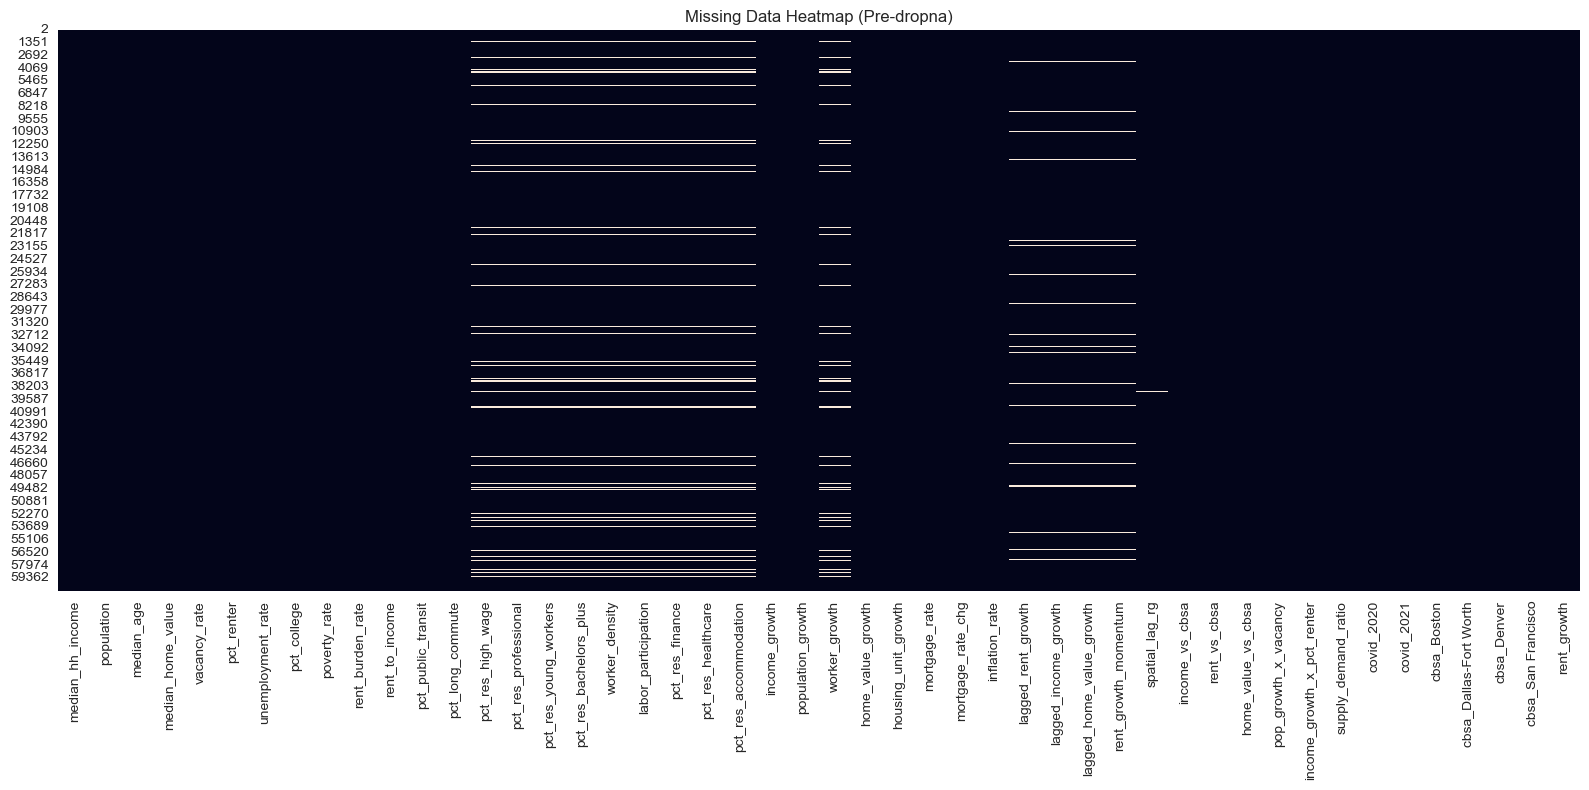

In [15]:
# Missing data heatmap
fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(df_model[FEATURE_COLS + [TARGET]].isnull(), cbar=False, ax=ax)
ax.set_title('Missing Data Heatmap (Pre-dropna)')
plt.tight_layout(); plt.show()

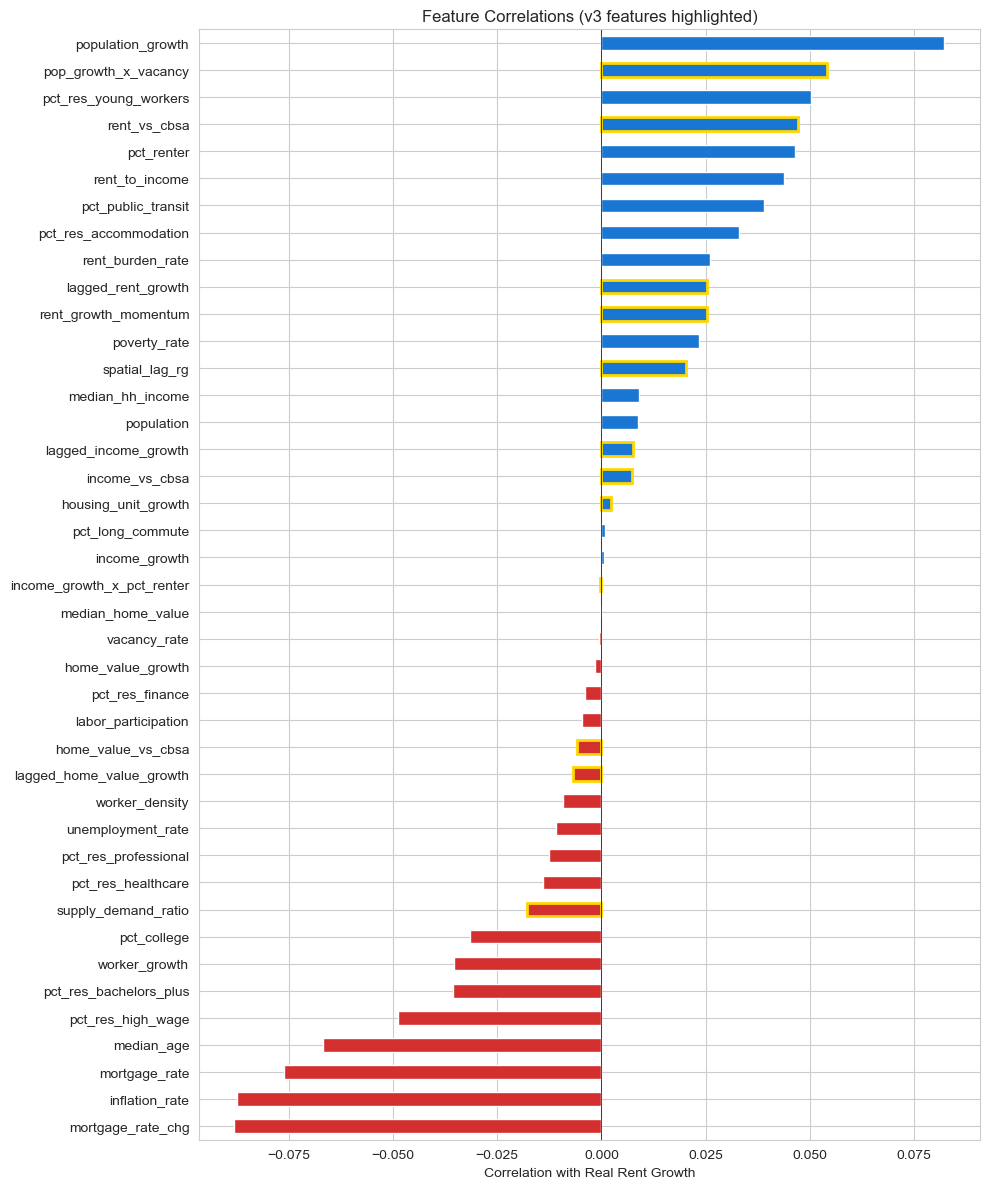

Gold-outlined bars = new v3 features

Top 5 positive: {'pct_renter': 0.04654965510465531, 'rent_vs_cbsa': 0.0472940454530027, 'pct_res_young_workers': 0.050287556740776715, 'pop_growth_x_vacancy': 0.054260515307055654, 'population_growth': 0.08235845473648408}
Top 5 negative: {'mortgage_rate_chg': -0.08807484724495267, 'inflation_rate': -0.08758525853855076, 'mortgage_rate': -0.07607534521694335, 'median_age': -0.06678907104613568, 'pct_res_high_wage': -0.0487279515183579}


In [16]:
# Correlation with rent growth
cont = [f for f in FEATURE_COLS if not f.startswith('cbsa_') and not f.startswith('covid_')]
corr_t = df_clean[cont + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()
fig, ax = plt.subplots(figsize=(10, 12))
colors = ['#d32f2f' if v < 0 else '#1976d2' for v in corr_t]
corr_t.plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('Correlation with Real Rent Growth')
ax.set_title('Feature Correlations (v3 features highlighted)')
ax.axvline(x=0, color='black', lw=0.5)
# Highlight v3 features
v3_feats = {'lagged_rent_growth','lagged_income_growth','lagged_home_value_growth',
            'rent_growth_momentum','spatial_lag_rg','income_vs_cbsa','rent_vs_cbsa',
            'home_value_vs_cbsa','pop_growth_x_vacancy','income_growth_x_pct_renter',
            'supply_demand_ratio','housing_unit_growth'}
for i, label in enumerate(corr_t.index):
    if label in v3_feats:
        ax.get_children()[i].set_edgecolor('gold')
        ax.get_children()[i].set_linewidth(2)
plt.tight_layout(); plt.show()
print('Gold-outlined bars = new v3 features')
print(f'\nTop 5 positive: {corr_t.tail(5).to_dict()}')
print(f'Top 5 negative: {corr_t.head(5).to_dict()}')

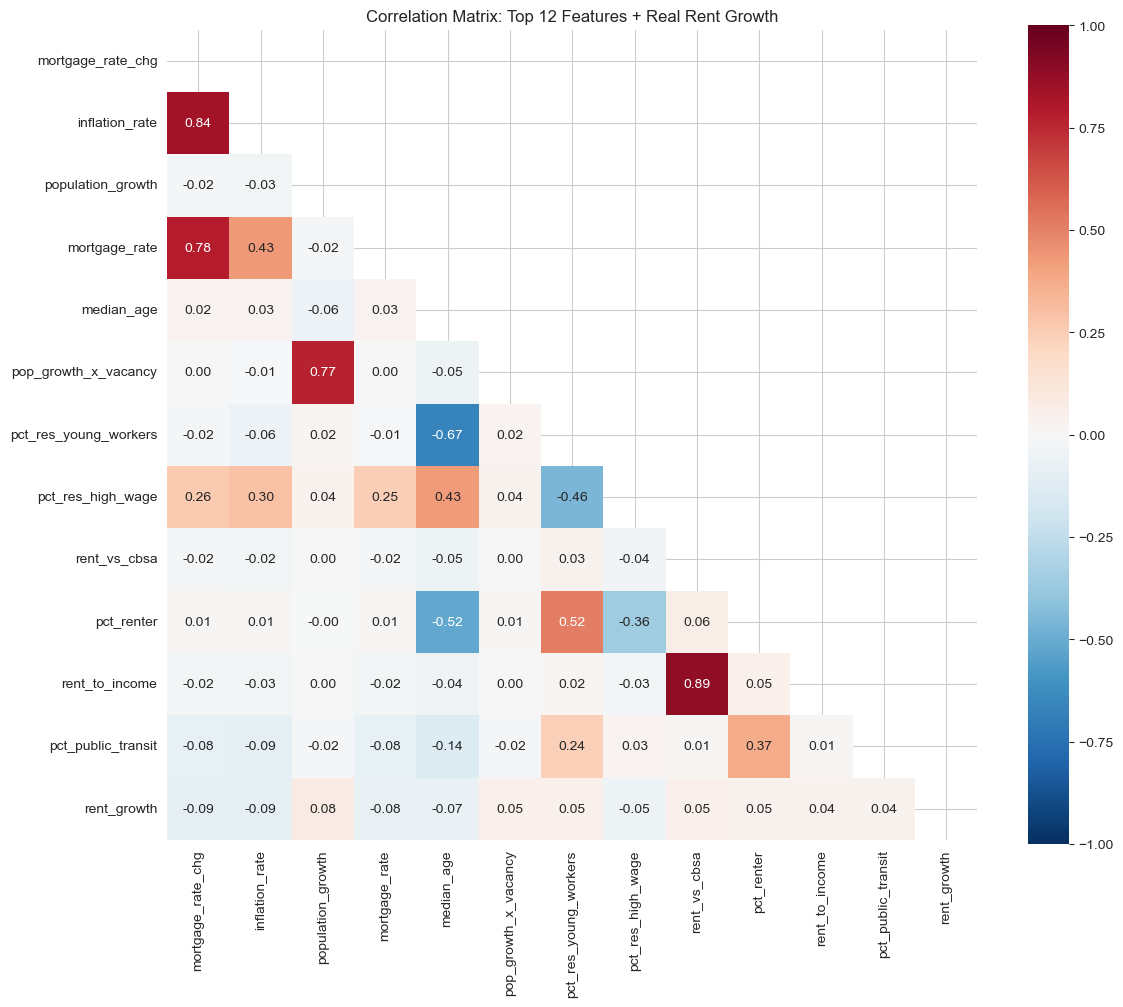

In [17]:
# Correlation matrix - top features
top_f = corr_t.abs().nlargest(12).index.tolist()
cm = df_clean[top_f + [TARGET]].corr()
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, mask=np.triu(np.ones_like(cm, dtype=bool)), annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('Correlation Matrix: Top 12 Features + Real Rent Growth')
plt.tight_layout(); plt.show()

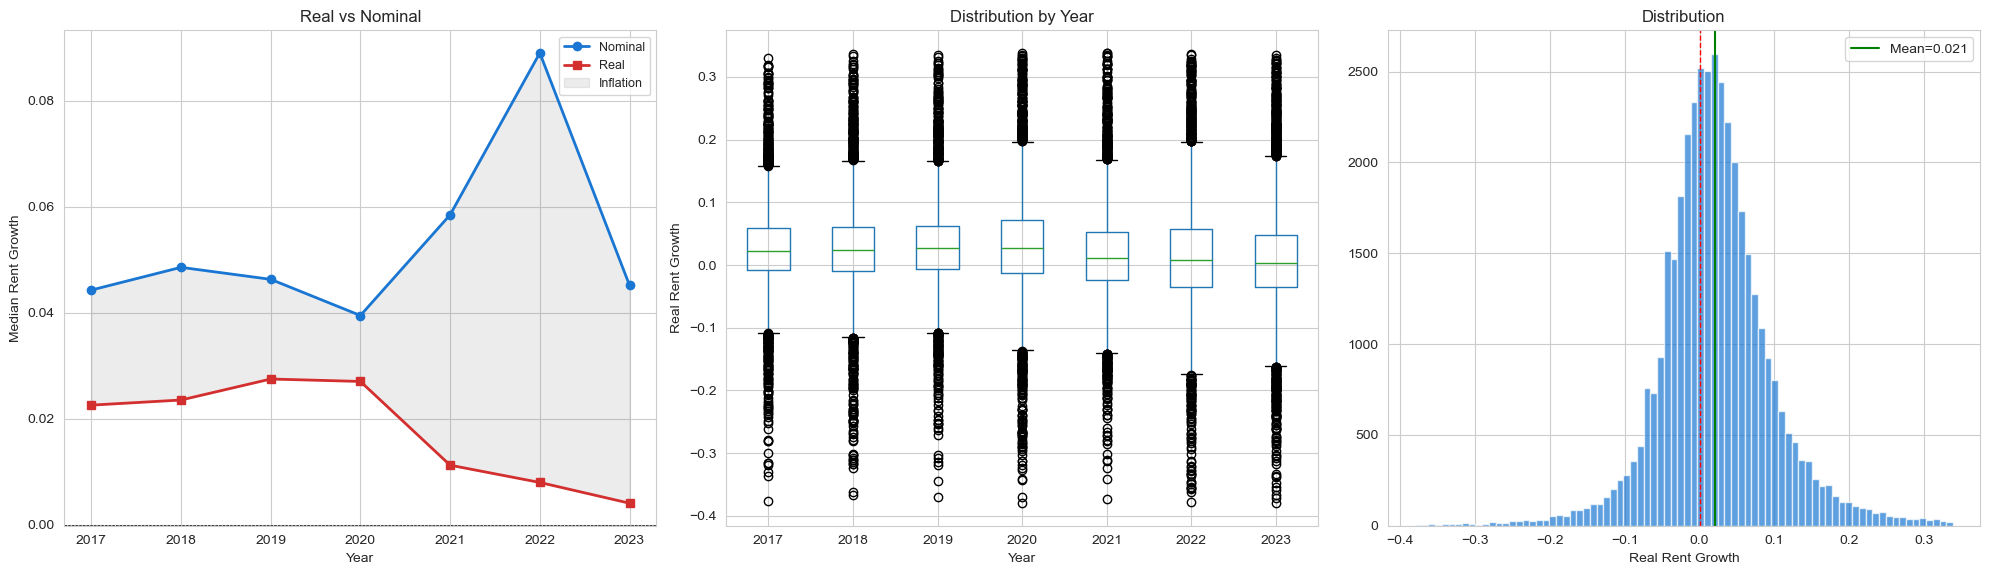

In [18]:
# Rent growth over time
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
ys = df_clean.groupby('year').agg(real=(TARGET,'median'), nom=('nominal_rent_growth','median')).reset_index()
axes[0].plot(ys['year'], ys['nom'], 'o-', label='Nominal', lw=2, color='#1976d2')
axes[0].plot(ys['year'], ys['real'], 's-', label='Real', lw=2, color='#d32f2f')
axes[0].fill_between(ys['year'], ys['nom'], ys['real'], alpha=0.15, color='gray', label='Inflation')
axes[0].axhline(y=0, color='black', lw=0.5, ls='--')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Median Rent Growth')
axes[0].set_title('Real vs Nominal'); axes[0].legend(fontsize=9)

df_clean.boxplot(column=TARGET, by='year', ax=axes[1])
axes[1].set_xlabel('Year'); axes[1].set_ylabel('Real Rent Growth')
axes[1].set_title('Distribution by Year'); plt.suptitle('')

axes[2].hist(df_clean[TARGET], bins=80, color='#1976d2', alpha=0.7, edgecolor='white')
axes[2].axvline(x=0, color='red', lw=1, ls='--')
axes[2].axvline(x=df_clean[TARGET].mean(), color='green', lw=1.5, label=f'Mean={df_clean[TARGET].mean():.3f}')
axes[2].set_xlabel('Real Rent Growth'); axes[2].set_title('Distribution'); axes[2].legend()
plt.tight_layout(); plt.show()

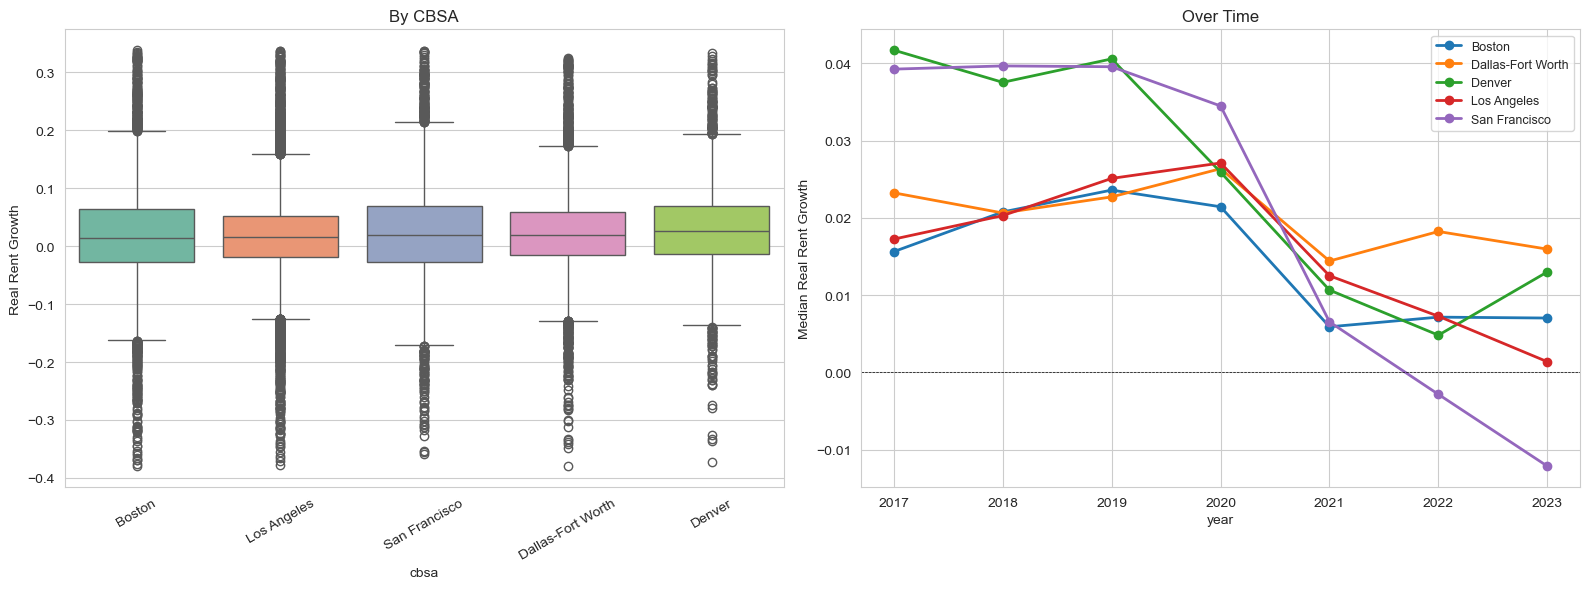

In [19]:
# CBSA comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
co = df_clean.groupby('cbsa')[TARGET].median().sort_values().index
sns.boxplot(data=df_clean, x='cbsa', y=TARGET, order=co, ax=axes[0], palette='Set2')
axes[0].set_ylabel('Real Rent Growth'); axes[0].set_title('By CBSA'); axes[0].tick_params(axis='x', rotation=30)
df_clean.groupby(['cbsa','year'])[TARGET].median().unstack(level=0).plot(ax=axes[1], marker='o', lw=2)
axes[1].set_ylabel('Median Real Rent Growth'); axes[1].set_title('Over Time')
axes[1].axhline(y=0, color='black', lw=0.5, ls='--'); axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

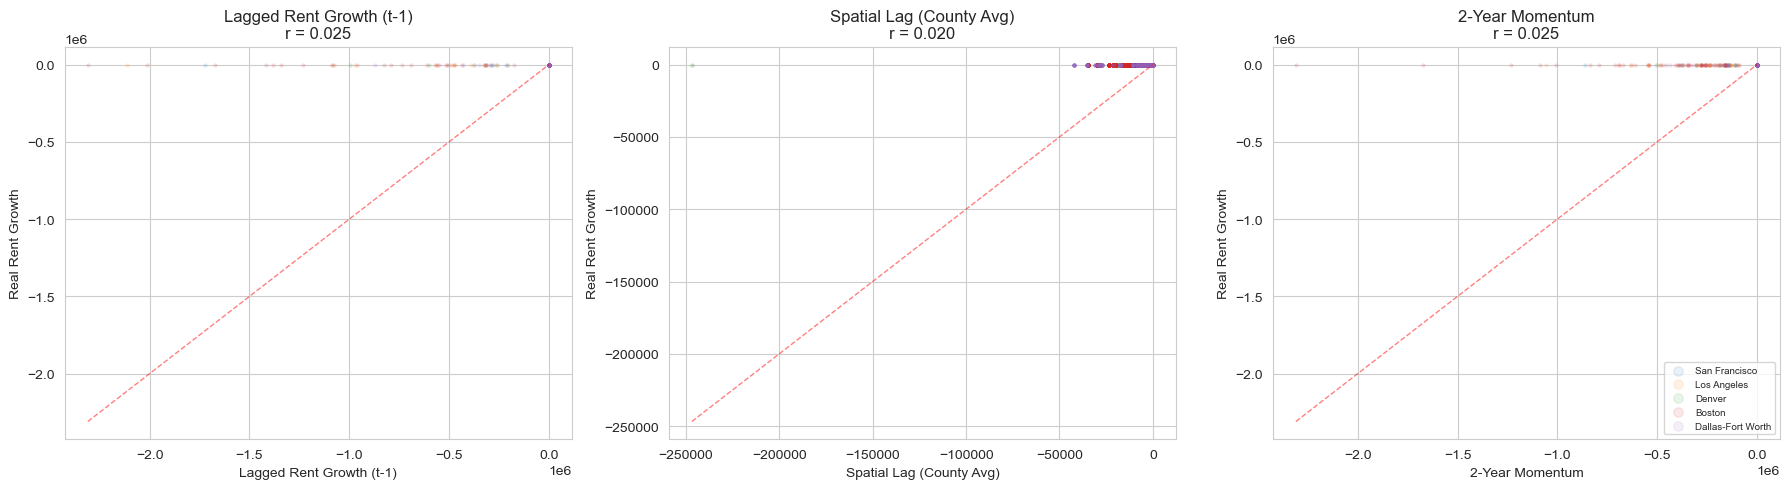

In [20]:
# Lagged rent growth scatter - key new feature
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (feat, label) in zip(axes, [
    ('lagged_rent_growth', 'Lagged Rent Growth (t-1)'),
    ('spatial_lag_rg', 'Spatial Lag (County Avg)'),
    ('rent_growth_momentum', '2-Year Momentum'),
]):
    for cbsa in df_clean['cbsa'].unique():
        mask = df_clean['cbsa'] == cbsa
        ax.scatter(df_clean.loc[mask, feat], df_clean.loc[mask, TARGET], alpha=0.1, s=5, label=cbsa)
    ax.set_xlabel(label); ax.set_ylabel('Real Rent Growth')
    r = df_clean[feat].corr(df_clean[TARGET])
    ax.set_title(f'{label}\nr = {r:.3f}')
    ax.plot([df_clean[feat].min(), df_clean[feat].max()],
            [df_clean[feat].min(), df_clean[feat].max()], 'r--', lw=1, alpha=0.5)
axes[2].legend(fontsize=7, markerscale=3)
plt.tight_layout(); plt.show()

---
## 4. Modeling

### Model Suite
| Model | Type | Purpose |
|-------|------|---------|
| OLS | Linear | Interpretable coefficients, significance testing |
| Lasso | Linear + L1 | Feature selection via regularization |
| Random Forest | Ensemble | Non-linear importance, robust baseline |
| XGBoost | Gradient Boosted | Strong tabular performance |
| LightGBM | Gradient Boosted | Fast, native categoricals, often best on tabular |
| CatBoost | Gradient Boosted | Handles categoricals, ordered boosting |
| Panel FE | Fixed Effects | Controls for tract-level unobserved heterogeneity |
| Two-Stage | Decomposition | Separates macro vs local drivers |

In [21]:
# Train/test split
X = df_clean[FEATURE_COLS].values
y = df_clean[TARGET].values

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df_clean.index, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_train)
X_te_s = scaler.transform(X_test)

# Also create temporal split for robustness check
temporal_mask = df_clean['year'] <= 2021
X_temp_train = df_clean.loc[temporal_mask, FEATURE_COLS].values
y_temp_train = df_clean.loc[temporal_mask, TARGET].values
X_temp_test = df_clean.loc[~temporal_mask, FEATURE_COLS].values
y_temp_test = df_clean.loc[~temporal_mask, TARGET].values

print(f'Random split  - Train: {X_train.shape[0]:,}  Test: {X_test.shape[0]:,}  Features: {X_train.shape[1]}')
print(f'Temporal split - Train (<=2021): {X_temp_train.shape[0]:,}  Test (2022-23): {X_temp_test.shape[0]:,}')

Random split  - Train: 32,194  Test: 8,049  Features: 47
Temporal split - Train (<=2021): 26,377  Test (2022-23): 13,866


In [22]:
# === OLS ===
X_tr_ols = sm.add_constant(X_tr_s)
X_te_ols = sm.add_constant(X_te_s)
ols_model = sm.OLS(y_train, X_tr_ols).fit()
y_ols_tr = ols_model.predict(X_tr_ols)
y_ols_te = ols_model.predict(X_te_ols)
print(f'=== OLS === Train R2: {ols_model.rsquared:.4f} | Test R2: {r2_score(y_test, y_ols_te):.4f} | Adj R2: {ols_model.rsquared_adj:.4f}')

# Significant features
ols_df = pd.DataFrame({'Feature': ['const']+FEATURE_COLS, 'Coef': ols_model.params,
    'P': ols_model.pvalues}).set_index('Feature')
sig = ols_df[(ols_df['P'] < 0.05) & (ols_df.index != 'const')].sort_values('Coef', key=abs, ascending=False)
print(f'\nSignificant features (p<0.05): {len(sig)}/{len(FEATURE_COLS)}')
print(sig[['Coef','P']].head(15).to_string())

=== OLS === Train R2: 0.0326 | Test R2: 0.0245 | Adj R2: 0.0312

Significant features (p<0.05): 19/47
                            Coef             P
Feature                                       
population_growth       0.009128  2.267978e-37
mortgage_rate          -0.007244  3.358487e-10
covid_2021             -0.005071  4.042617e-11
housing_unit_growth    -0.004720  8.986045e-14
pct_res_high_wage       0.003464  1.013466e-02
cbsa_Denver             0.003386  2.313371e-10
pct_renter              0.003366  3.814945e-05
cbsa_Dallas-Fort Worth  0.003273  8.865282e-06
median_age             -0.003065  1.399753e-05
rent_burden_rate        0.003002  5.399612e-10
rent_vs_cbsa            0.002789  9.186315e-03
pct_public_transit      0.002757  1.110730e-05
poverty_rate           -0.002536  4.900677e-04
labor_participation     0.002413  1.267531e-04
pct_res_finance        -0.002195  4.924330e-03


In [23]:
# === Lasso ===
lasso_cv = LassoCV(alphas=np.logspace(-6, -1, 100), cv=5, random_state=42, max_iter=10000)
lasso_cv.fit(X_tr_s, y_train)
y_las_tr = lasso_cv.predict(X_tr_s)
y_las_te = lasso_cv.predict(X_te_s)
lasso_coefs = pd.Series(lasso_cv.coef_, index=FEATURE_COLS)
print(f'=== Lasso === Alpha: {lasso_cv.alpha_:.6f} | Train: {r2_score(y_train,y_las_tr):.4f} | Test: {r2_score(y_test,y_las_te):.4f}')
print(f'Non-zero: {(lasso_coefs!=0).sum()}/{len(lasso_coefs)}')
print('\nRetained features:')
print(lasso_coefs[lasso_coefs!=0].sort_values(key=abs, ascending=False).to_string())

=== Lasso === Alpha: 0.000148 | Train: 0.0321 | Test: 0.0250
Non-zero: 37/47

Retained features:
population_growth             0.008325
mortgage_rate                -0.005452
housing_unit_growth          -0.004130
covid_2021                   -0.003998
cbsa_Denver                   0.003117
median_age                   -0.002942
rent_vs_cbsa                  0.002776
pct_renter                    0.002638
cbsa_Dallas-Fort Worth        0.002608
rent_burden_rate              0.002585
pct_public_transit            0.002480
poverty_rate                 -0.002254
labor_participation           0.002115
mortgage_rate_chg            -0.002015
inflation_rate               -0.001951
pct_college                  -0.001584
worker_density               -0.001535
cbsa_San Francisco            0.001418
pct_res_finance              -0.001235
unemployment_rate            -0.000998
pop_growth_x_vacancy         -0.000775
covid_2020                   -0.000761
pct_res_high_wage             0.000634
median

In [24]:
# === Random Forest ===
rf_model = RandomForestRegressor(n_estimators=500, max_depth=15, min_samples_leaf=20, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_rf_tr = rf_model.predict(X_train)
y_rf_te = rf_model.predict(X_test)
print(f'=== RF === Train: {r2_score(y_train,y_rf_tr):.4f} | Test: {r2_score(y_test,y_rf_te):.4f}')

=== RF === Train: 0.4028 | Test: 0.1951


In [25]:
# === XGBoost ===
xgb_model = xgb.XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
y_xgb_tr = xgb_model.predict(X_train)
y_xgb_te = xgb_model.predict(X_test)
print(f'=== XGB === Train: {r2_score(y_train,y_xgb_tr):.4f} | Test: {r2_score(y_test,y_xgb_te):.4f}')

=== XGB === Train: 0.6522 | Test: 0.2919


In [26]:
# === LightGBM ===
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000, max_depth=8, learning_rate=0.03, num_leaves=63,
    subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
    min_child_samples=30, random_state=42, n_jobs=-1, verbose=-1
)
lgb_model.fit(X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)]
)
y_lgb_tr = lgb_model.predict(X_train)
y_lgb_te = lgb_model.predict(X_test)
print(f'=== LightGBM === Train: {r2_score(y_train,y_lgb_tr):.4f} | Test: {r2_score(y_test,y_lgb_te):.4f}')
print(f'Best iteration: {lgb_model.best_iteration_}')

=== LightGBM === Train: 0.7995 | Test: 0.4549
Best iteration: 998


In [27]:
# === CatBoost ===
cat_model = CatBoostRegressor(
    iterations=1000, depth=8, learning_rate=0.03,
    l2_leaf_reg=3.0, subsample=0.8, random_seed=42,
    verbose=0, early_stopping_rounds=50
)
cat_model.fit(X_train, y_train, eval_set=(X_test, y_test), verbose=0)
y_cat_tr = cat_model.predict(X_train)
y_cat_te = cat_model.predict(X_test)
print(f'=== CatBoost === Train: {r2_score(y_train,y_cat_tr):.4f} | Test: {r2_score(y_test,y_cat_te):.4f}')
print(f'Best iteration: {cat_model.best_iteration_}')

=== CatBoost === Train: 0.4978 | Test: 0.2492
Best iteration: 999


### Panel Fixed Effects
Controls for **time-invariant tract characteristics** (location quality, school district, proximity to transit, etc.)
that we can't observe directly. The within-estimator answers: *"When a tract's features change over time,
how does its rent growth respond?"*

In [28]:
# === Panel Fixed Effects (linearmodels) ===
panel_df = df_clean.set_index(['GEOID', 'year'])
# Remove features that don't vary within tract (CBSA dummies)
panel_features = [f for f in FEATURE_COLS if not f.startswith('cbsa_')]

panel_mod = PanelOLS(panel_df[TARGET], panel_df[panel_features], entity_effects=True, drop_absorbed=True)
panel_res = panel_mod.fit(cov_type='clustered', cluster_entity=True)
print(f'=== Panel FE === Within R2: {panel_res.rsquared_within:.4f} | Overall R2: {panel_res.rsquared_overall:.4f}')
print(f'Entities (tracts): {panel_res.entity_info.total}')
print(f'\nTop significant coefficients:')
panel_summary = pd.DataFrame({
    'Coef': panel_res.params,
    'P': panel_res.pvalues
})
panel_sig = panel_summary[panel_summary['P'] < 0.05].sort_values('Coef', key=abs, ascending=False)
print(panel_sig.head(15).to_string())

=== Panel FE === Within R2: 0.0266 | Overall R2: -0.1474
Entities (tracts): 7244.0

Top significant coefficients:
                         Coef             P
inflation_rate      -0.236428  1.739335e-03
population_growth    0.153102  0.000000e+00
housing_unit_growth -0.084497  4.669531e-05
poverty_rate        -0.084381  7.670309e-12
pct_college          0.063645  2.132051e-06
pct_res_high_wage    0.061554  1.757431e-03
unemployment_rate   -0.054248  1.152651e-02
pct_public_transit   0.046884  9.804674e-03
rent_burden_rate     0.039219  2.866656e-10
worker_density       0.029290  4.760171e-04
covid_2021          -0.014835  1.489263e-09
mortgage_rate       -0.007918  9.694934e-11
covid_2020          -0.006958  1.819838e-03
median_age          -0.000758  2.616182e-03


### Two-Stage Decomposition
Separates **macro drivers** (what moves entire markets) from **local drivers** (what makes individual tracts different).
- **Stage 1:** Predict CBSA-year average rent growth from macro variables
- **Stage 2:** Predict tract deviation from CBSA average using local features
- **Combined:** Stage 1 + Stage 2 = full prediction

In [29]:
# === Two-Stage Model ===
df_train_2s = df_clean.loc[idx_train].copy()
df_test_2s = df_clean.loc[idx_test].copy()

# Stage 1: CBSA-year average from macro
cbsa_year_train = df_train_2s.groupby(['cbsa', 'year']).agg(
    cbsa_rg=(TARGET, 'mean'),
    mortgage_rate=('mortgage_rate', 'first'),
    inflation_rate=('inflation_rate', 'first'),
    mortgage_rate_chg=('mortgage_rate_chg', 'first'),
    covid_2020=('covid_2020', 'first'),
    covid_2021=('covid_2021', 'first'),
).reset_index()
cbsa_dum_s1 = pd.get_dummies(cbsa_year_train['cbsa'], prefix='cbsa', dtype=int).drop(columns='cbsa_Los Angeles')
stage1_X = pd.concat([cbsa_year_train[['mortgage_rate','inflation_rate','mortgage_rate_chg','covid_2020','covid_2021']], cbsa_dum_s1], axis=1)
stage1_y = cbsa_year_train['cbsa_rg']
stage1_model = sm.OLS(stage1_y, sm.add_constant(stage1_X)).fit()
print(f'Stage 1 (macro -> CBSA avg): R2 = {stage1_model.rsquared:.4f}, n = {len(stage1_y)}')
print(stage1_model.summary().tables[1])

# Stage 1 predictions for test
cbsa_year_test = df_test_2s[['cbsa','year','mortgage_rate','inflation_rate','mortgage_rate_chg','covid_2020','covid_2021']].drop_duplicates()
cbsa_dum_s1_te = pd.get_dummies(cbsa_year_test['cbsa'], prefix='cbsa', dtype=int).drop(columns='cbsa_Los Angeles')
stage1_X_te = pd.concat([cbsa_year_test[['mortgage_rate','inflation_rate','mortgage_rate_chg','covid_2020','covid_2021']].reset_index(drop=True), cbsa_dum_s1_te.reset_index(drop=True)], axis=1)
cbsa_year_test = cbsa_year_test.reset_index(drop=True)
cbsa_year_test['stage1_pred'] = stage1_model.predict(sm.add_constant(stage1_X_te))

# Stage 2: Local deviation
train_cbsa_means = df_train_2s.groupby(['cbsa','year'])[TARGET].transform('mean')
df_train_2s['deviation'] = df_train_2s[TARGET] - train_cbsa_means
local_features = [f for f in FEATURE_COLS if f not in ['mortgage_rate','inflation_rate','mortgage_rate_chg','covid_2020','covid_2021'] and not f.startswith('cbsa_')]
stage2_model = lgb.LGBMRegressor(n_estimators=500, max_depth=6, learning_rate=0.03, verbose=-1, n_jobs=-1, random_state=42)
stage2_model.fit(df_train_2s[local_features].values, df_train_2s['deviation'].values)
print(f'\nStage 2 (local -> deviation): Train R2 = {r2_score(df_train_2s["deviation"], stage2_model.predict(df_train_2s[local_features].values)):.4f}')

# Combined prediction on test
df_test_2s = df_test_2s.merge(cbsa_year_test[['cbsa','year','stage1_pred']], on=['cbsa','year'], how='left')
df_test_2s['stage2_pred'] = stage2_model.predict(df_test_2s[local_features].values)
df_test_2s['combined_pred'] = df_test_2s['stage1_pred'] + df_test_2s['stage2_pred']
y_2s_te = df_test_2s['combined_pred'].values
y_2s_actual = df_test_2s[TARGET].values

print(f'\n=== Two-Stage Combined === Test R2: {r2_score(y_2s_actual, y_2s_te):.4f}')
print(f'  Stage 1 alone Test R2: {r2_score(y_2s_actual, df_test_2s["stage1_pred"].values):.4f}')

Stage 1 (macro -> CBSA avg): R2 = 0.6833, n = 35
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0.0510      0.014      3.768      0.001       0.023       0.079
mortgage_rate             -0.0050      0.002     -2.039      0.052      -0.010    5.02e-05
inflation_rate            -0.1655      0.207     -0.799      0.432      -0.592       0.261
mortgage_rate_chg         -0.0018      0.006     -0.320      0.752      -0.013       0.010
covid_2020                -0.0076      0.005     -1.462      0.156      -0.018       0.003
covid_2021                -0.0173      0.007     -2.465      0.021      -0.032      -0.003
cbsa_Boston                0.0008      0.004      0.179      0.859      -0.008       0.010
cbsa_Dallas-Fort Worth     0.0058      0.004      1.300      0.205      -0.003       0.015
cbsa_Denver                0.0123      0.


Stage 2 (local -> deviation): Train R2 = 0.4859

=== Two-Stage Combined === Test R2: 0.3147
  Stage 1 alone Test R2: 0.0092


---\n## 5. Results & Comparison

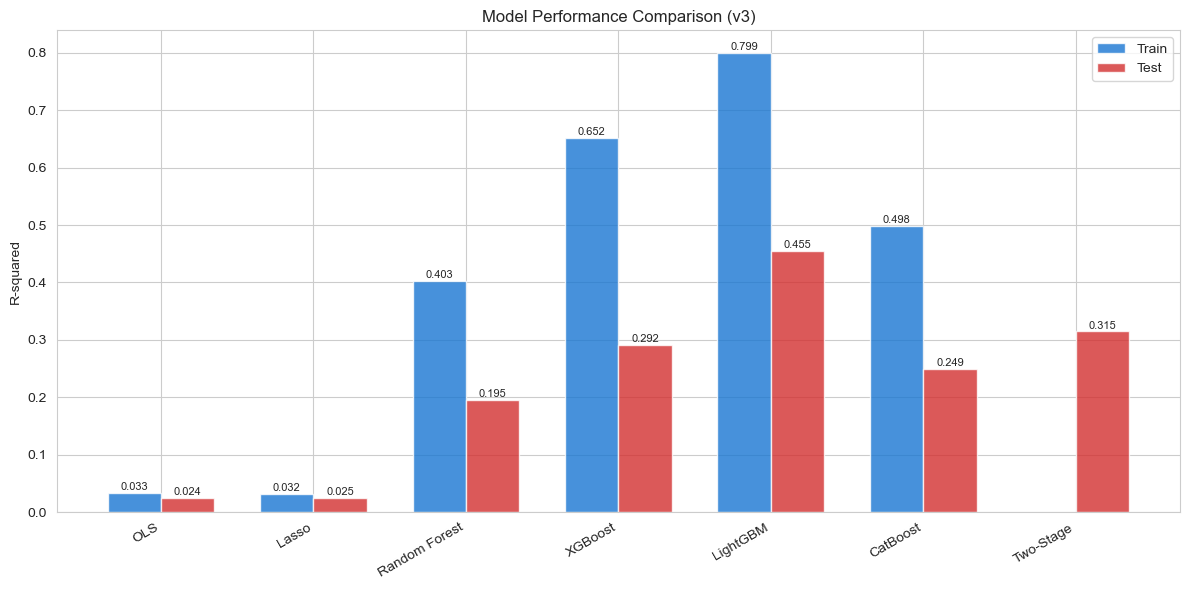

        Model  Train R2  Test R2  Test MAE
          OLS  0.032649 0.024485  0.053323
        Lasso  0.032121 0.024954  0.053307
Random Forest  0.402807 0.195106  0.047707
      XGBoost  0.652243 0.291892  0.044570
     LightGBM  0.799458 0.454892  0.034530
     CatBoost  0.497824 0.249172  0.046080
    Two-Stage       NaN 0.314738  0.041047


In [30]:
# Model comparison
results = pd.DataFrame({
    'Model': ['OLS', 'Lasso', 'Random Forest', 'XGBoost', 'LightGBM', 'CatBoost', 'Two-Stage'],
    'Train R2': [
        r2_score(y_train, y_ols_tr), r2_score(y_train, y_las_tr),
        r2_score(y_train, y_rf_tr), r2_score(y_train, y_xgb_tr),
        r2_score(y_train, y_lgb_tr), r2_score(y_train, y_cat_tr),
        np.nan,  # two-stage train not directly comparable
    ],
    'Test R2': [
        r2_score(y_test, y_ols_te), r2_score(y_test, y_las_te),
        r2_score(y_test, y_rf_te), r2_score(y_test, y_xgb_te),
        r2_score(y_test, y_lgb_te), r2_score(y_test, y_cat_te),
        r2_score(y_2s_actual, y_2s_te),
    ],
    'Test MAE': [
        mean_absolute_error(y_test, y_ols_te), mean_absolute_error(y_test, y_las_te),
        mean_absolute_error(y_test, y_rf_te), mean_absolute_error(y_test, y_xgb_te),
        mean_absolute_error(y_test, y_lgb_te), mean_absolute_error(y_test, y_cat_te),
        mean_absolute_error(y_2s_actual, y_2s_te),
    ],
})

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(results))
w = 0.35
b1 = ax.bar(x - w/2, results['Train R2'].fillna(0), w, label='Train', color='#1976d2', alpha=0.8)
b2 = ax.bar(x + w/2, results['Test R2'], w, label='Test', color='#d32f2f', alpha=0.8)
ax.set_ylabel('R-squared'); ax.set_title('Model Performance Comparison (v3)')
ax.set_xticks(x); ax.set_xticklabels(results['Model'], rotation=30, ha='right')
ax.legend()
for bar in b1:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{bar.get_height():.3f}', ha='center', fontsize=8)
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{bar.get_height():.3f}', ha='center', fontsize=8)
plt.tight_layout(); plt.show()
print(results.to_string(index=False))

In [31]:
# Temporal split robustness check
print('=== Temporal Split Robustness (Train <=2021, Test 2022-23) ===')
scaler_t = StandardScaler()
X_tt_s = scaler_t.fit_transform(X_temp_train)
X_ttest_s = scaler_t.transform(X_temp_test)

temporal_results = {}
for name, model_class, kwargs, use_scaled in [
    ('OLS', None, {}, True),
    ('LightGBM', lgb.LGBMRegressor, dict(n_estimators=500, max_depth=8, learning_rate=0.03, verbose=-1, n_jobs=-1, random_state=42), False),
    ('XGBoost', xgb.XGBRegressor, dict(n_estimators=500, max_depth=6, learning_rate=0.05, random_state=42, n_jobs=-1), False),
]:
    if name == 'OLS':
        m = sm.OLS(y_temp_train, sm.add_constant(X_tt_s, has_constant='add')).fit()
        pred = m.predict(sm.add_constant(X_ttest_s, has_constant='add'))
    else:
        m = model_class(**kwargs)
        m.fit(X_temp_train, y_temp_train)
        pred = m.predict(X_temp_test)
    r2 = r2_score(y_temp_test, pred)
    temporal_results[name] = r2
    print(f'  {name}: Test R2 = {r2:.4f}')
print('\nNote: temporal split is harder (predicting into a different macro regime)')

=== Temporal Split Robustness (Train <=2021, Test 2022-23) ===
  OLS: Test R2 = -0.0345


  LightGBM: Test R2 = -0.0833


  XGBoost: Test R2 = -0.1743

Note: temporal split is harder (predicting into a different macro regime)


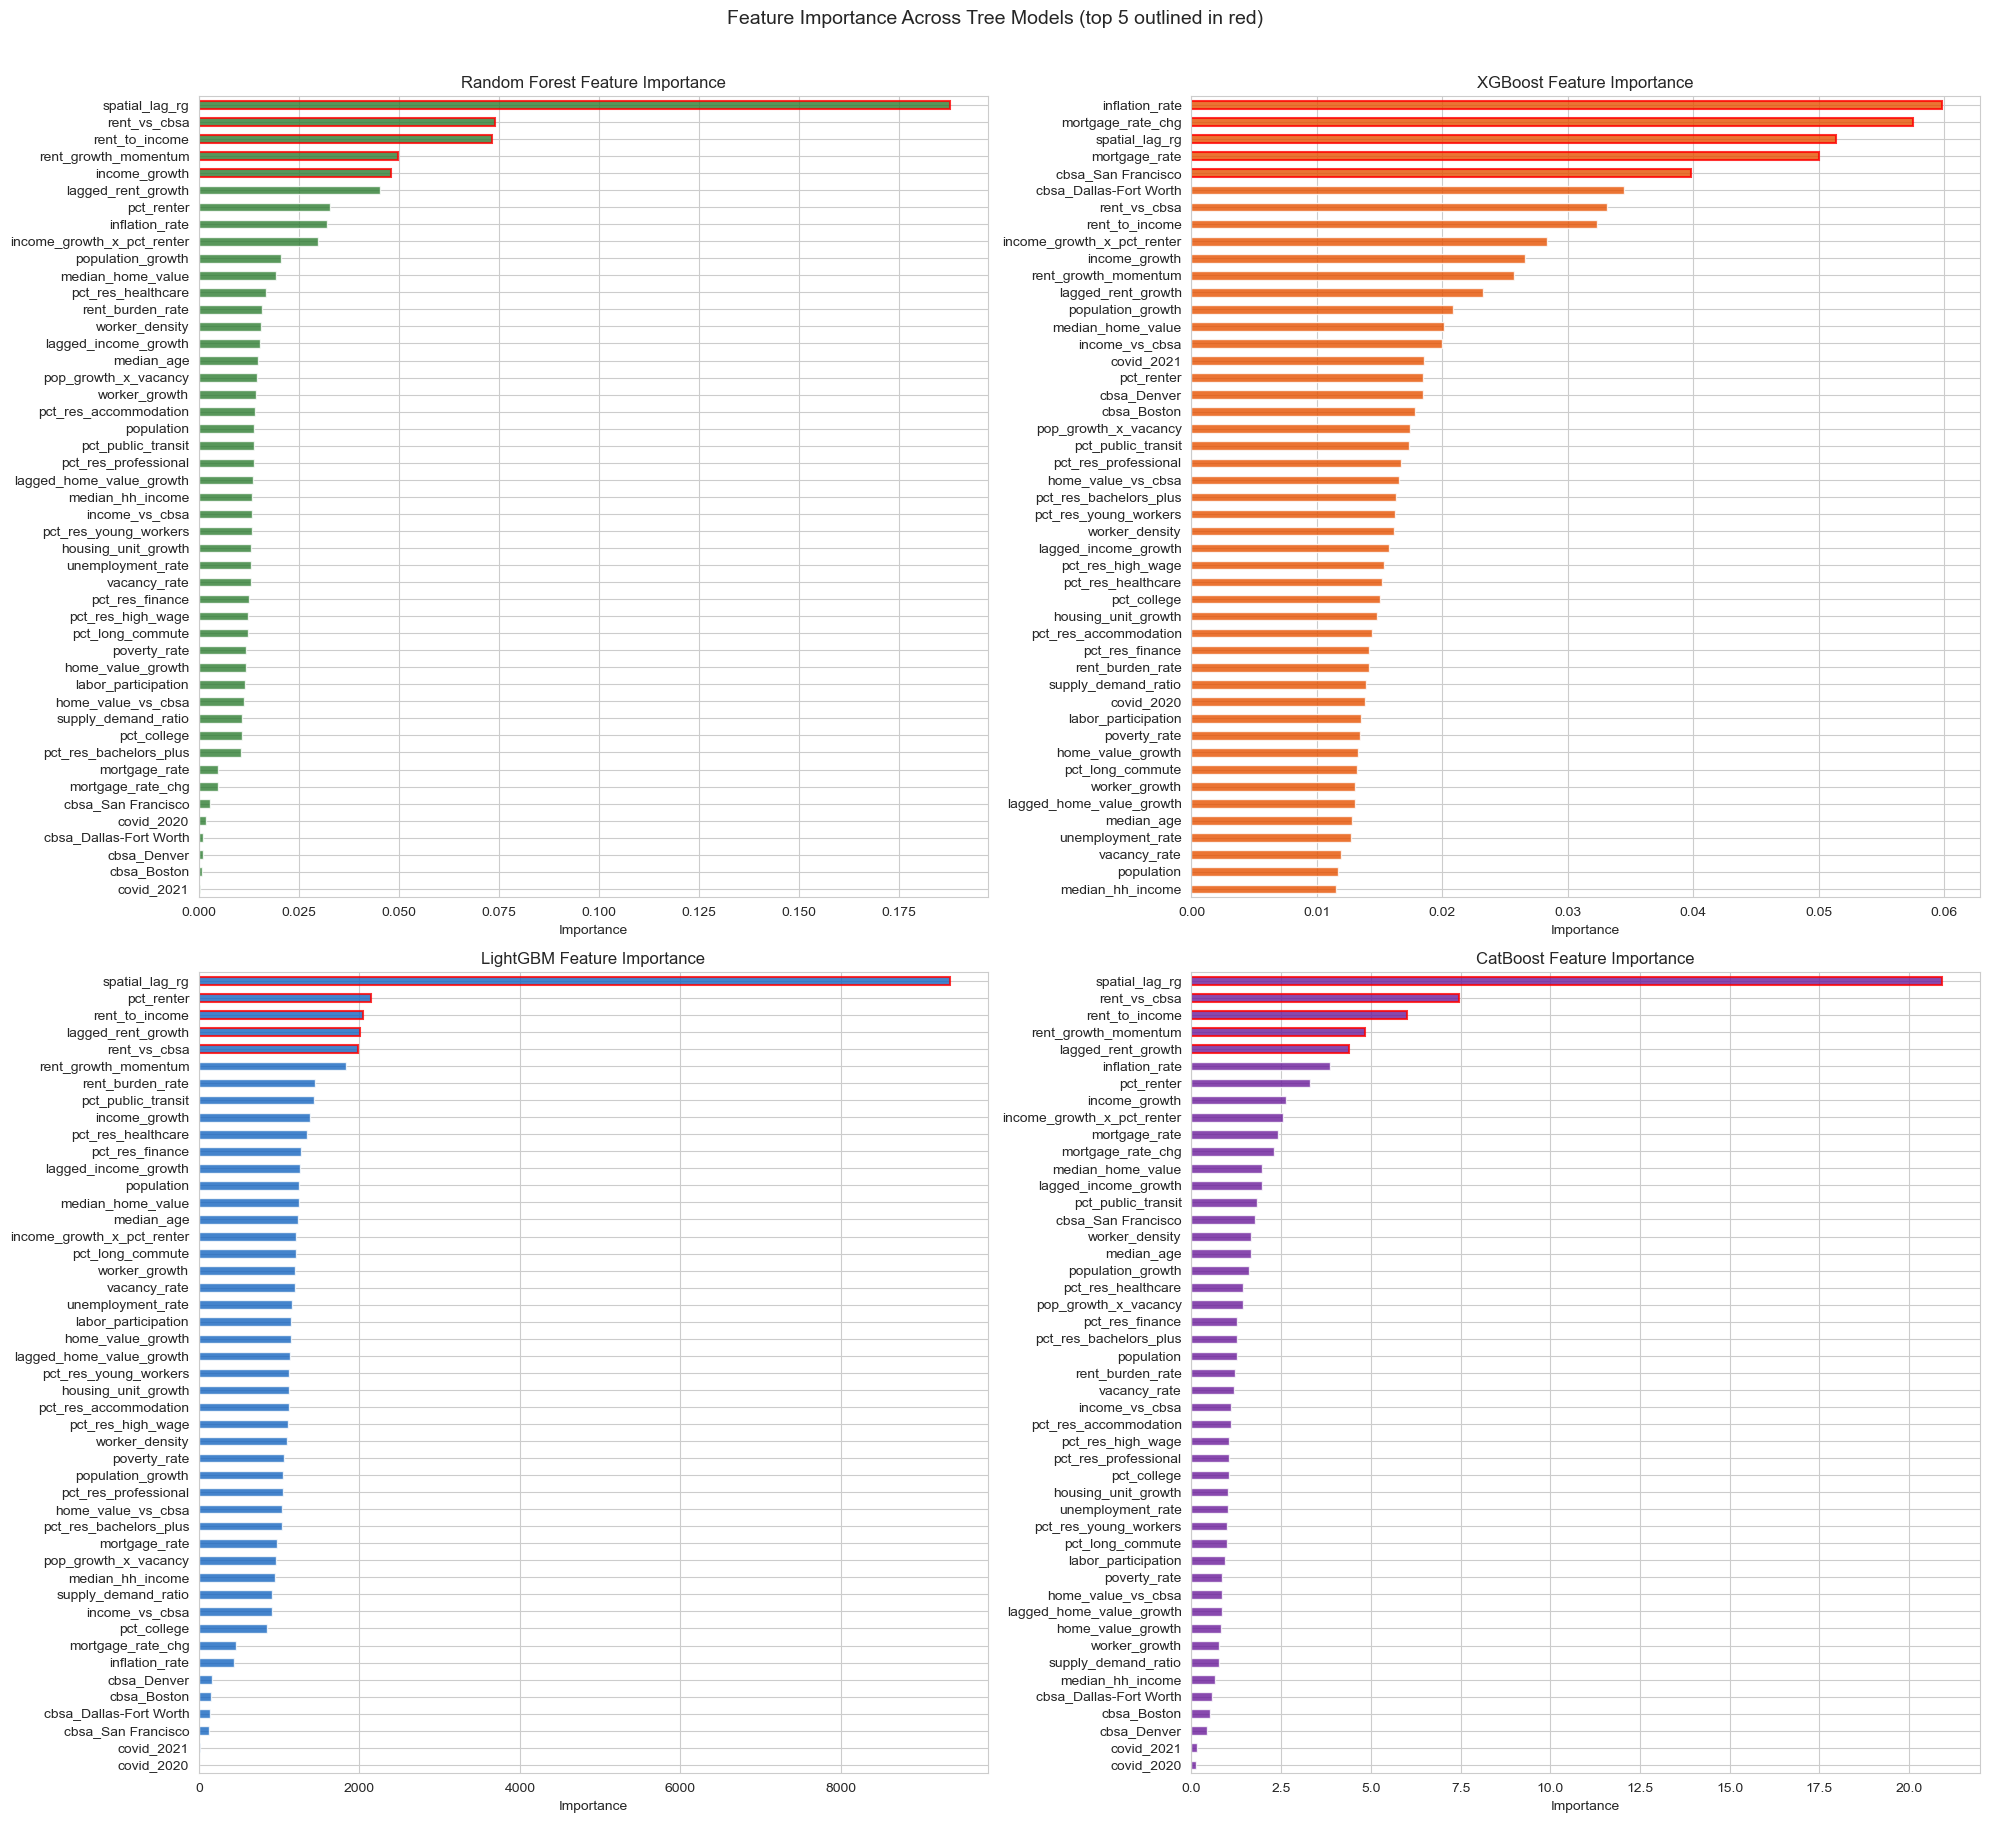

In [32]:
# Feature importance comparison (4 tree models)
rf_imp = pd.Series(rf_model.feature_importances_, index=FEATURE_COLS)
xgb_imp = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS)
lgb_imp = pd.Series(lgb_model.feature_importances_, index=FEATURE_COLS)
cat_imp = pd.Series(cat_model.feature_importances_, index=FEATURE_COLS)

fig, axes = plt.subplots(2, 2, figsize=(20, 18))
for ax, (imp, name, color) in zip(axes.flat, [
    (rf_imp, 'Random Forest', '#2e7d32'),
    (xgb_imp, 'XGBoost', '#e65100'),
    (lgb_imp, 'LightGBM', '#1565c0'),
    (cat_imp, 'CatBoost', '#6a1b9a'),
]):
    sorted_imp = imp.sort_values()
    bars = sorted_imp.plot(kind='barh', ax=ax, color=color, alpha=0.8)
    ax.set_title(f'{name} Feature Importance')
    ax.set_xlabel('Importance')
    # Highlight top 5
    for i, (idx, val) in enumerate(sorted_imp.items()):
        if i >= len(sorted_imp) - 5:
            ax.get_children()[i].set_edgecolor('red')
            ax.get_children()[i].set_linewidth(1.5)
plt.suptitle('Feature Importance Across Tree Models (top 5 outlined in red)', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

In [33]:
# Consensus feature importance
importance_df = pd.DataFrame({
    'RF': rf_imp, 'XGB': xgb_imp, 'LightGBM': lgb_imp, 'CatBoost': cat_imp,
    'OLS |coef|': ols_df.loc[FEATURE_COLS, 'Coef'].abs().values,
    'OLS p': ols_df.loc[FEATURE_COLS, 'P'].values,
    'Lasso': lasso_coefs.values,
}, index=FEATURE_COLS)

# Rank each feature across tree models
for col in ['RF','XGB','LightGBM','CatBoost']:
    importance_df[f'{col}_rank'] = importance_df[col].rank(ascending=False)
importance_df['Avg_tree_rank'] = importance_df[['RF_rank','XGB_rank','LightGBM_rank','CatBoost_rank']].mean(axis=1)
importance_df = importance_df.sort_values('Avg_tree_rank')

print('=== Consensus Feature Importance (sorted by avg tree rank) ===')
display_cols = ['OLS |coef|', 'OLS p', 'Lasso', 'RF', 'XGB', 'LightGBM', 'CatBoost', 'Avg_tree_rank']
print(importance_df[display_cols].round(4).to_string())

=== Consensus Feature Importance (sorted by avg tree rank) ===
                            OLS |coef|   OLS p   Lasso      RF     XGB  LightGBM  CatBoost  Avg_tree_rank
spatial_lag_rg                  0.0003  0.4974 -0.0001  0.1879  0.0514      9359   20.9305          1.500
rent_vs_cbsa                    0.0028  0.0092  0.0028  0.0740  0.0331      1981    7.4697          4.000
rent_to_income                  0.0004  0.7193  0.0002  0.0734  0.0323      2041    6.0084          4.250
rent_growth_momentum            0.0010  0.1431 -0.0003  0.0499  0.0257      1833    4.8383          6.250
lagged_rent_growth              0.0006  0.3860  0.0000  0.0452  0.0232      2003    4.3999          6.750
income_growth                   0.0019  0.6122 -0.0000  0.0481  0.0266      1381    2.6485          8.000
pct_renter                      0.0034  0.0000  0.0026  0.0328  0.0185      2141    3.3169          8.250
income_growth_x_pct_renter      0.0024  0.4949 -0.0003  0.0297  0.0283      1208    2.559

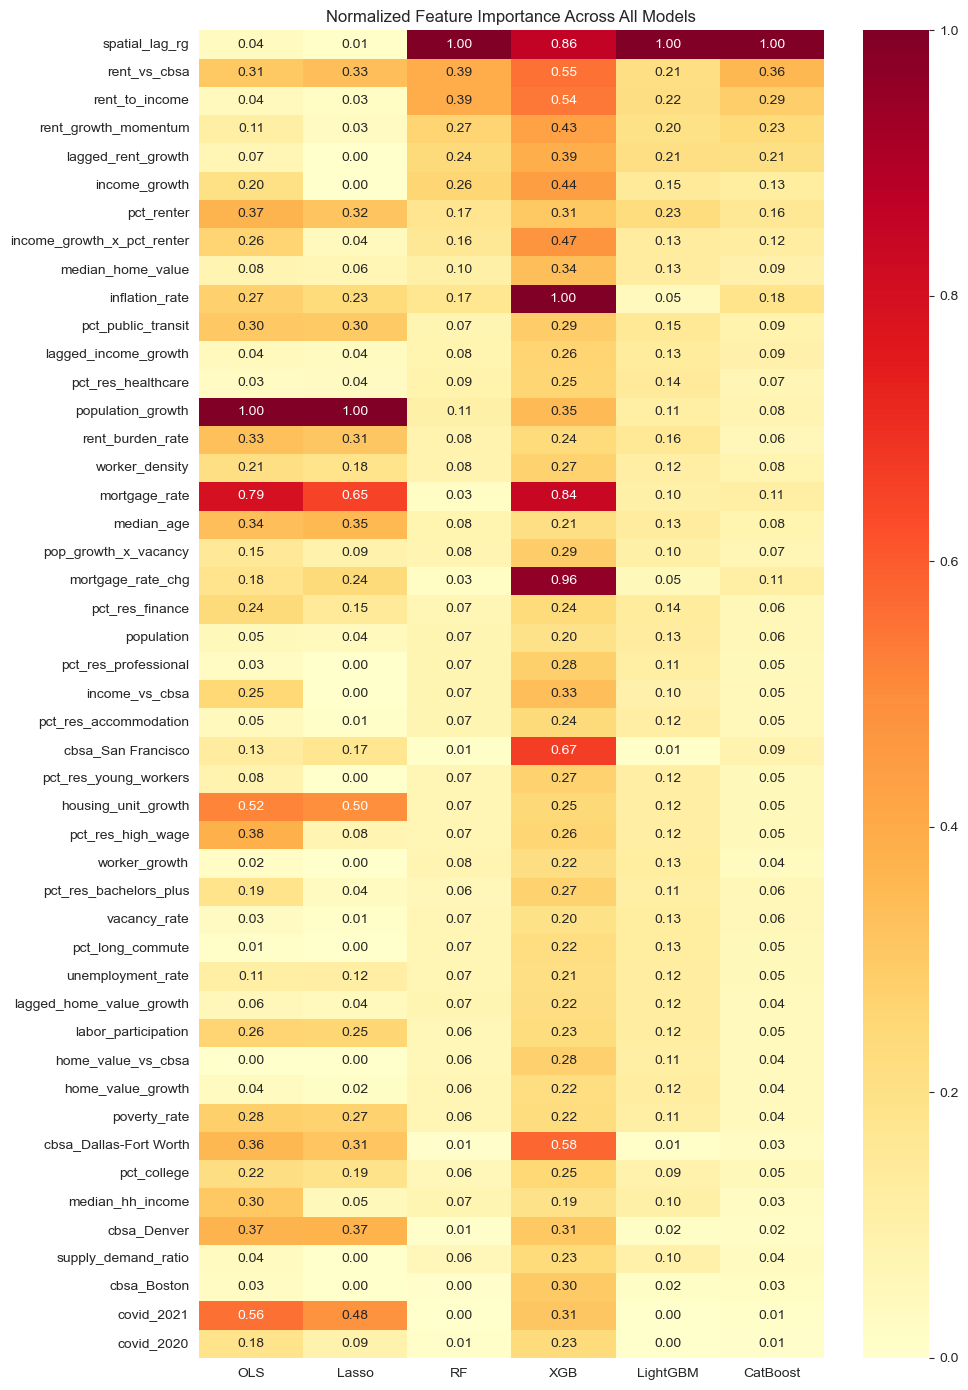

In [34]:
# Normalized importance heatmap
norm_imp = pd.DataFrame({
    'OLS': importance_df['OLS |coef|'] / importance_df['OLS |coef|'].max(),
    'Lasso': importance_df['Lasso'].abs() / importance_df['Lasso'].abs().max(),
    'RF': importance_df['RF'] / importance_df['RF'].max(),
    'XGB': importance_df['XGB'] / importance_df['XGB'].max(),
    'LightGBM': importance_df['LightGBM'] / importance_df['LightGBM'].max(),
    'CatBoost': importance_df['CatBoost'] / importance_df['CatBoost'].max(),
}, index=importance_df.index)

fig, ax = plt.subplots(figsize=(10, 14))
sns.heatmap(norm_imp, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, vmin=0, vmax=1)
ax.set_title('Normalized Feature Importance Across All Models')
plt.tight_layout(); plt.show()

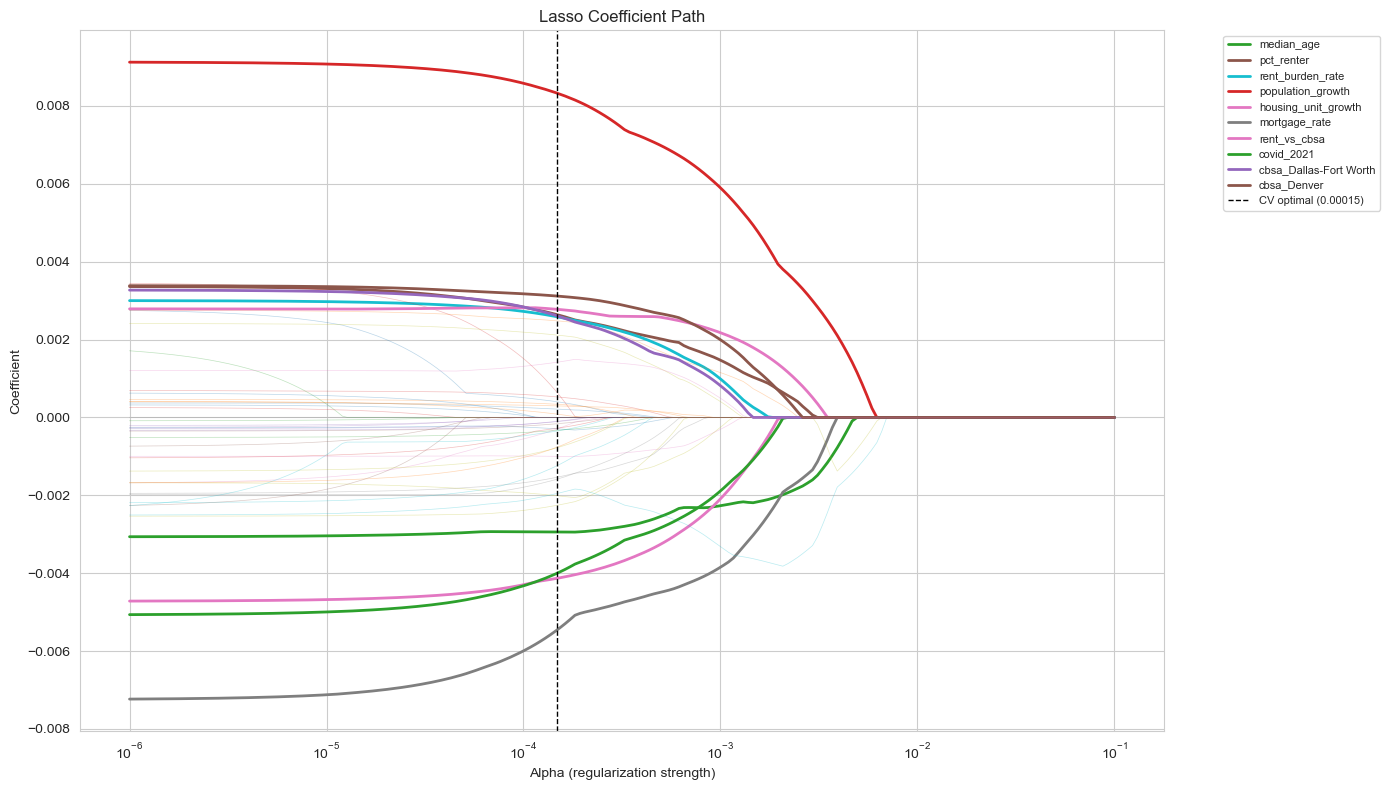

In [35]:
# Lasso regularization path
alphas = np.logspace(-6, -1, 200)
coef_paths = []
for a in alphas:
    lt = Lasso(alpha=a, max_iter=10000)
    lt.fit(X_tr_s, y_train)
    coef_paths.append(lt.coef_)
coef_paths = np.array(coef_paths)

fig, ax = plt.subplots(figsize=(14, 8))
# Only label top features
top_lasso = lasso_coefs.abs().nlargest(10).index
for i, f in enumerate(FEATURE_COLS):
    lw = 2 if f in top_lasso.values else 0.5
    alpha = 1.0 if f in top_lasso.values else 0.3
    line, = ax.plot(alphas, coef_paths[:, i], lw=lw, alpha=alpha)
    if f in top_lasso.values:
        line.set_label(f)
ax.set_xscale('log'); ax.set_xlabel('Alpha (regularization strength)')
ax.set_ylabel('Coefficient')
ax.set_title('Lasso Coefficient Path')
ax.axvline(x=lasso_cv.alpha_, color='black', ls='--', lw=1, label=f'CV optimal ({lasso_cv.alpha_:.5f})')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

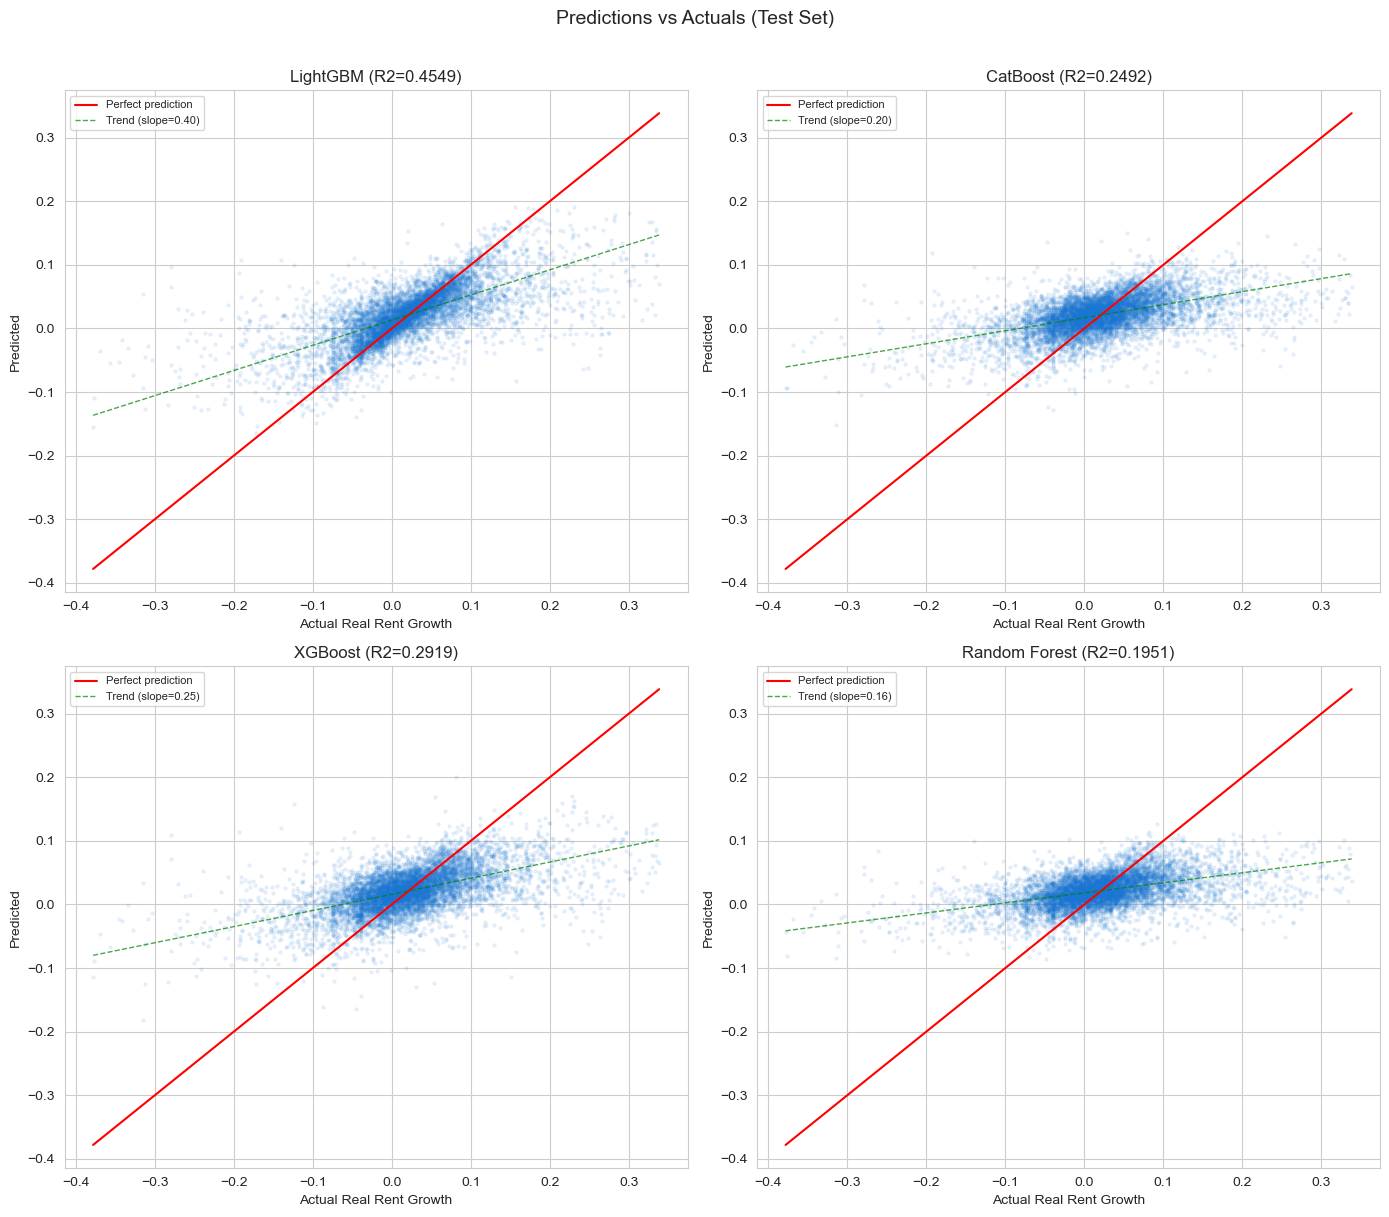

In [36]:
# Predictions vs actuals - best models
best_preds = [
    ('LightGBM', y_lgb_te), ('CatBoost', y_cat_te),
    ('XGBoost', y_xgb_te), ('Random Forest', y_rf_te),
]
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, (nm, yp) in zip(axes.flat, best_preds):
    ax.scatter(y_test, yp, alpha=0.08, s=5, color='#1976d2')
    lims = [min(y_test.min(), yp.min()), max(y_test.max(), yp.max())]
    ax.plot(lims, lims, 'r-', lw=1.5, label='Perfect prediction')
    # Add trend line
    z = np.polyfit(y_test, yp, 1)
    ax.plot(lims, np.poly1d(z)(lims), 'g--', lw=1, alpha=0.7, label=f'Trend (slope={z[0]:.2f})')
    ax.set_xlabel('Actual Real Rent Growth')
    ax.set_ylabel('Predicted')
    ax.set_title(f'{nm} (R2={r2_score(y_test, yp):.4f})')
    ax.legend(fontsize=8)
plt.suptitle('Predictions vs Actuals (Test Set)', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

---
## 6. Tract-Level Prediction Time Series

Select representative tracts and compare predicted vs actual rent growth over time.
Uses the best-performing model to generate full-sample predictions (in-sample + out-of-sample).

In [37]:
# Fit best model on full data for tract-level time series
best_model = lgb.LGBMRegressor(
    n_estimators=1000, max_depth=8, learning_rate=0.03, num_leaves=63,
    subsample=0.8, colsample_bytree=0.8, min_child_samples=30,
    random_state=42, n_jobs=-1, verbose=-1
)
best_model.fit(X, y)
df_clean['predicted_rg'] = best_model.predict(X)

# Select representative tracts: 2 per CBSA (highest and lowest avg rent growth)
selected_tracts = []
for cbsa in ['Boston', 'Dallas-Fort Worth', 'San Francisco', 'Denver', 'Los Angeles']:
    cbsa_tracts = df_clean[df_clean['cbsa'] == cbsa].groupby('GEOID').agg(
        mean_rg=(TARGET, 'mean'),
        n_years=(TARGET, 'count'),
    )
    # Only tracts with data for all years
    full_tracts = cbsa_tracts[cbsa_tracts['n_years'] == cbsa_tracts['n_years'].max()]
    if len(full_tracts) >= 2:
        selected_tracts.append((cbsa, full_tracts['mean_rg'].idxmax(), 'High growth'))
        selected_tracts.append((cbsa, full_tracts['mean_rg'].idxmin(), 'Low growth'))

print(f'Selected {len(selected_tracts)} tracts for time series visualization:')
for cbsa, geoid, label in selected_tracts:
    avg = df_clean[df_clean['GEOID']==geoid][TARGET].mean()
    print(f'  {cbsa} ({label}): {geoid}  avg real rent growth = {avg:.3f}')

Selected 10 tracts for time series visualization:
  Boston (High growth): 25021420301  avg real rent growth = 0.096
  Boston (Low growth): 25021410100  avg real rent growth = -0.072
  Dallas-Fort Worth (High growth): 48139061100  avg real rent growth = 0.109
  Dallas-Fort Worth (Low growth): 48439106507  avg real rent growth = -0.073
  San Francisco (High growth): 06075023400  avg real rent growth = 0.118
  San Francisco (Low growth): 06081613800  avg real rent growth = -0.068
  Denver (High growth): 08031000102  avg real rent growth = 0.097
  Denver (Low growth): 08031003203  avg real rent growth = -0.029
  Los Angeles (High growth): 06037901101  avg real rent growth = 0.125
  Los Angeles (Low growth): 06037137104  avg real rent growth = -0.081


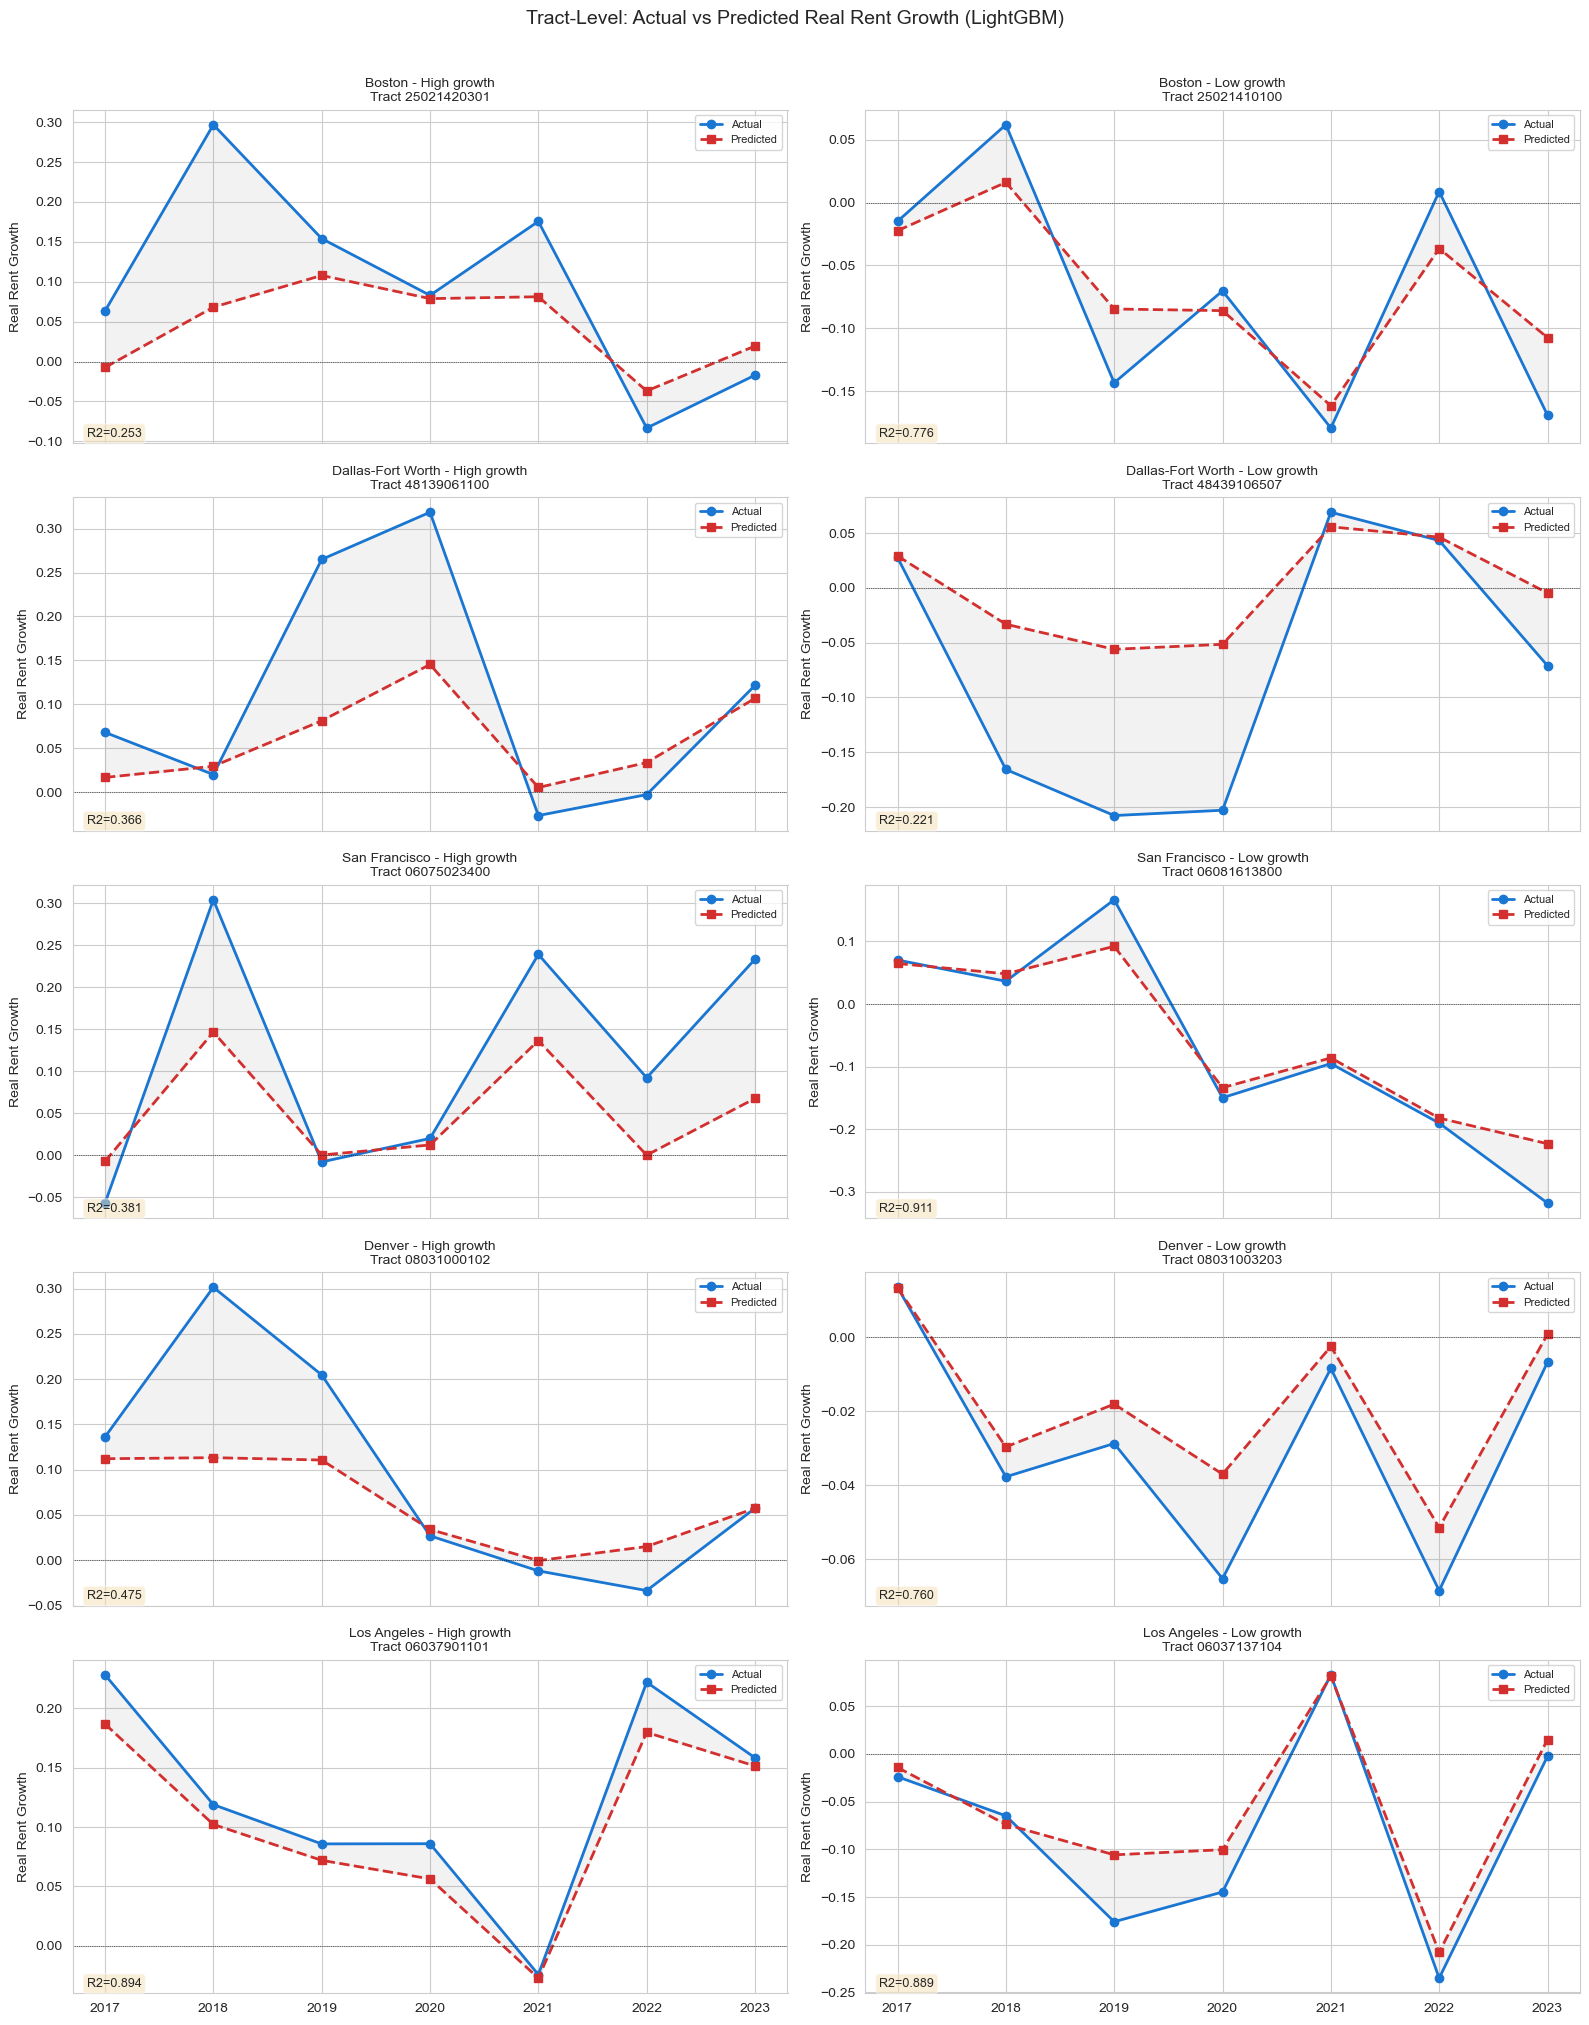

In [38]:
# Plot tract-level predictions vs actuals
n_tracts = len(selected_tracts)
n_cols = 2
n_rows = (n_tracts + 1) // 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows), sharex=True)
axes = axes.flat

for i, (cbsa, geoid, label) in enumerate(selected_tracts):
    ax = axes[i]
    tract_data = df_clean[df_clean['GEOID'] == geoid].sort_values('year')
    ax.plot(tract_data['year'], tract_data[TARGET], 'o-', color='#1976d2', lw=2, markersize=6, label='Actual')
    ax.plot(tract_data['year'], tract_data['predicted_rg'], 's--', color='#d32f2f', lw=2, markersize=6, label='Predicted')
    ax.fill_between(tract_data['year'], tract_data[TARGET], tract_data['predicted_rg'], alpha=0.1, color='gray')
    ax.axhline(y=0, color='black', lw=0.5, ls=':')
    ax.set_ylabel('Real Rent Growth')
    ax.set_title(f'{cbsa} - {label}\nTract {geoid}', fontsize=10)
    ax.legend(fontsize=8)
    r2 = r2_score(tract_data[TARGET], tract_data['predicted_rg'])
    ax.text(0.02, 0.02, f'R2={r2:.3f}', transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Remove extra axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Tract-Level: Actual vs Predicted Real Rent Growth (LightGBM)', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

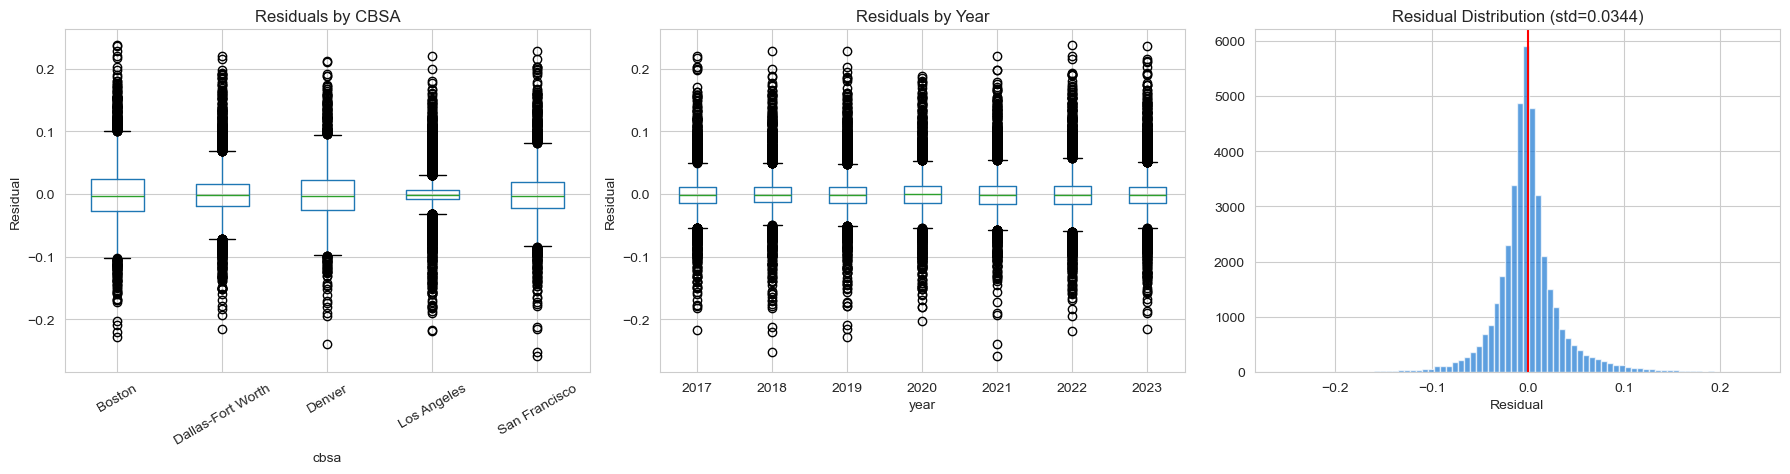

In [39]:
# Residual analysis by CBSA and year
df_clean['residual'] = df_clean[TARGET] - df_clean['predicted_rg']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Residuals by CBSA
df_clean.boxplot(column='residual', by='cbsa', ax=axes[0])
axes[0].set_title('Residuals by CBSA'); axes[0].set_ylabel('Residual'); plt.suptitle('')
axes[0].tick_params(axis='x', rotation=30)

# Residuals by year
df_clean.boxplot(column='residual', by='year', ax=axes[1])
axes[1].set_title('Residuals by Year'); axes[1].set_ylabel('Residual'); plt.suptitle('')

# Residual distribution
axes[2].hist(df_clean['residual'], bins=80, color='#1976d2', alpha=0.7, edgecolor='white')
axes[2].axvline(x=0, color='red', lw=1.5)
axes[2].set_xlabel('Residual'); axes[2].set_title(f'Residual Distribution (std={df_clean["residual"].std():.4f})')

plt.tight_layout(); plt.show()

### Tract Explorer
Modify the `EXPLORE_GEOID` variable below to view predictions for any tract in the dataset.
You can find tract GEOIDs from the data or look up tracts at [census.gov/cgi-bin/geo/shapefiles](https://www2.census.gov/geo/maps/dc10map/tract/).

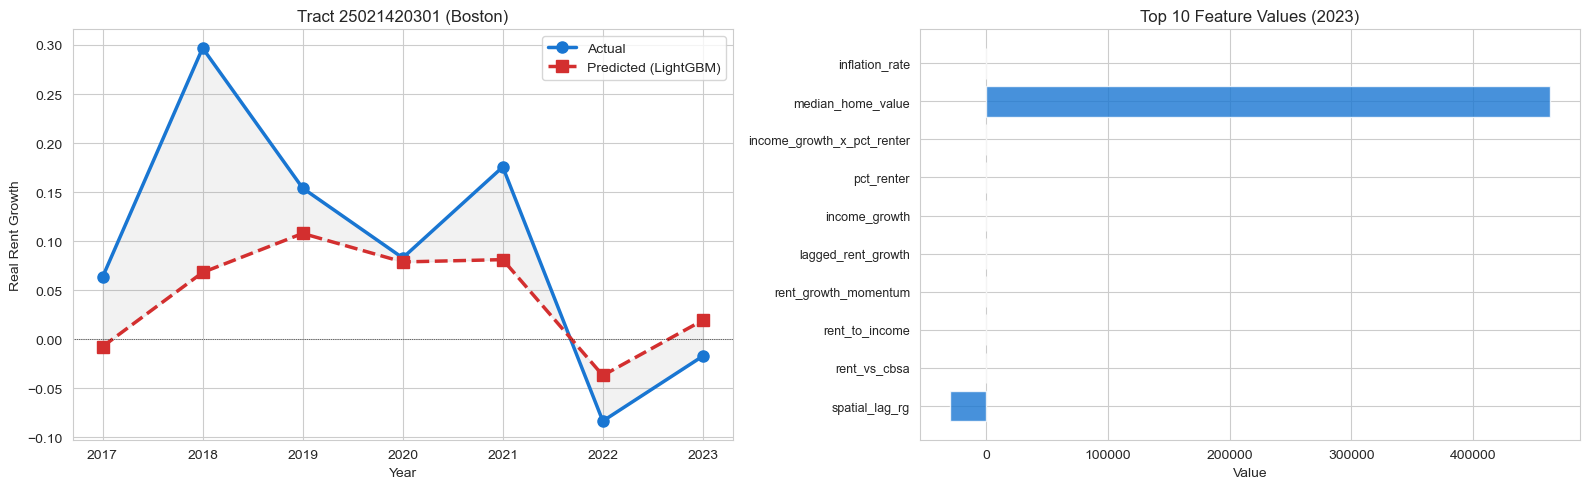


Tract 25021420301 (Boston)
  Years: 2017-2023 (7 obs)
  Avg real rent growth:  0.0961
  Avg predicted:         0.0445
  Tract R2:              0.2530



In [40]:
# ============================================================
# TRACT EXPLORER - Change the GEOID below to explore any tract
# ============================================================
EXPLORE_GEOID = selected_tracts[0][1]  # Default: first selected tract

tract = df_clean[df_clean['GEOID'] == EXPLORE_GEOID].sort_values('year')
if len(tract) == 0:
    print(f'Tract {EXPLORE_GEOID} not found. Available tracts:')
    print(df_clean['GEOID'].unique()[:20])
else:
    cbsa_name = tract['cbsa'].iloc[0]
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Rent growth time series
    axes[0].plot(tract['year'], tract[TARGET], 'o-', color='#1976d2', lw=2.5, markersize=8, label='Actual')
    axes[0].plot(tract['year'], tract['predicted_rg'], 's--', color='#d32f2f', lw=2.5, markersize=8, label='Predicted (LightGBM)')
    axes[0].fill_between(tract['year'], tract[TARGET], tract['predicted_rg'], alpha=0.1, color='gray')
    axes[0].axhline(y=0, color='black', lw=0.5, ls=':')
    axes[0].set_xlabel('Year'); axes[0].set_ylabel('Real Rent Growth')
    axes[0].set_title(f'Tract {EXPLORE_GEOID} ({cbsa_name})')
    axes[0].legend()

    # Feature values for this tract (latest year)
    latest = tract.iloc[-1]
    top_features = importance_df.head(10).index
    feat_vals = latest[top_features]
    axes[1].barh(range(len(feat_vals)), feat_vals.values, color='#1976d2', alpha=0.8)
    axes[1].set_yticks(range(len(feat_vals)))
    axes[1].set_yticklabels(top_features, fontsize=9)
    axes[1].set_title(f'Top 10 Feature Values ({int(latest["year"])})')
    axes[1].set_xlabel('Value')

    plt.tight_layout(); plt.show()

    # Summary stats
    print(f'\nTract {EXPLORE_GEOID} ({cbsa_name})')
    print(f'  Years: {tract["year"].min()}-{tract["year"].max()} ({len(tract)} obs)')
    print(f'  Avg real rent growth:  {tract[TARGET].mean():.4f}')
    print(f'  Avg predicted:         {tract["predicted_rg"].mean():.4f}')
    print(f'  Tract R2:              {r2_score(tract[TARGET], tract["predicted_rg"]):.4f}')
    print(f'  Latest median rent:    ${latest.get("median_gross_rent", "N/A"):,.0f}' if 'median_gross_rent' in tract.columns else '')

---
## 7. v2 vs v3 Comparison

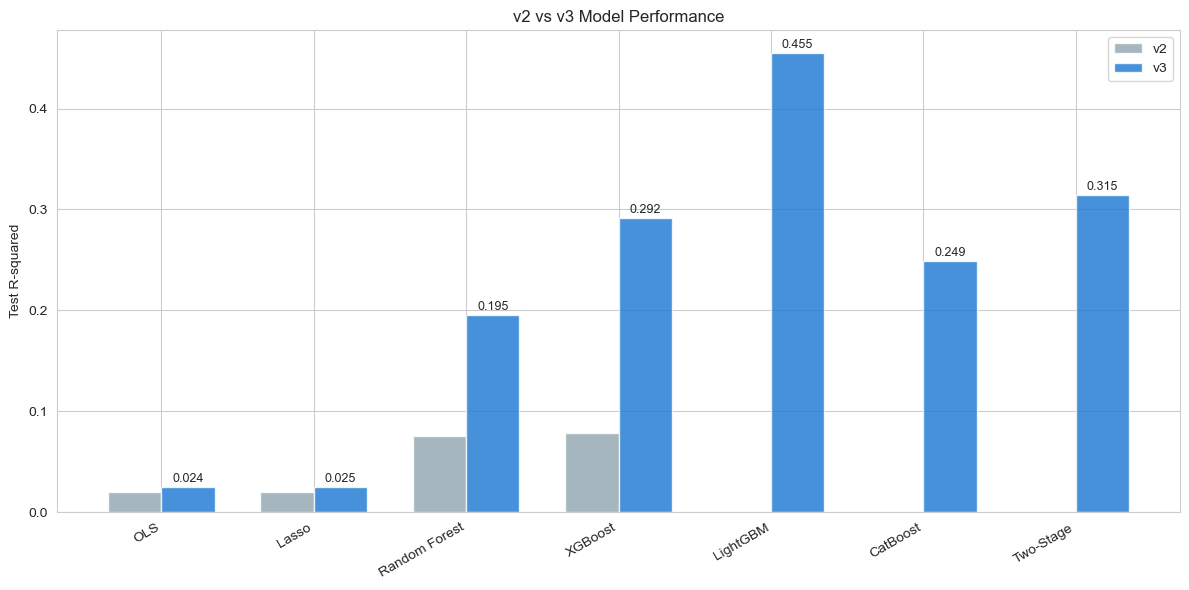

        Model  v2 Test R2  v3 Test R2  Improvement  Improvement %
          OLS      0.0201      0.0245       0.0044        21.8155
        Lasso      0.0202      0.0250       0.0048        23.5354
Random Forest      0.0756      0.1951       0.1195       158.0768
      XGBoost      0.0782      0.2919       0.2137       273.2632
     LightGBM         NaN      0.4549          NaN            NaN
     CatBoost         NaN      0.2492          NaN            NaN
    Two-Stage         NaN      0.3147          NaN            NaN


In [41]:
# v2 baseline results (from previous run)
v2_results = pd.DataFrame({
    'Model': ['OLS', 'Lasso', 'Random Forest', 'XGBoost'],
    'v2 Test R2': [0.0201, 0.0202, 0.0756, 0.0782],
})

v3_test_r2 = {
    'OLS': r2_score(y_test, y_ols_te),
    'Lasso': r2_score(y_test, y_las_te),
    'Random Forest': r2_score(y_test, y_rf_te),
    'XGBoost': r2_score(y_test, y_xgb_te),
}
v2_results['v3 Test R2'] = v2_results['Model'].map(v3_test_r2)
v2_results['Improvement'] = v2_results['v3 Test R2'] - v2_results['v2 Test R2']
v2_results['Improvement %'] = ((v2_results['v3 Test R2'] / v2_results['v2 Test R2']) - 1) * 100

# Add v3-only models
v3_only = pd.DataFrame({
    'Model': ['LightGBM', 'CatBoost', 'Two-Stage'],
    'v2 Test R2': [np.nan, np.nan, np.nan],
    'v3 Test R2': [r2_score(y_test, y_lgb_te), r2_score(y_test, y_cat_te), r2_score(y_2s_actual, y_2s_te)],
    'Improvement': [np.nan, np.nan, np.nan],
    'Improvement %': [np.nan, np.nan, np.nan],
})
comparison = pd.concat([v2_results, v3_only], ignore_index=True)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison))
w = 0.35
b1 = ax.bar(x[comparison['v2 Test R2'].notna()] - w/2, comparison.loc[comparison['v2 Test R2'].notna(), 'v2 Test R2'], w,
            label='v2', color='#90a4ae', alpha=0.8)
b2 = ax.bar(x + w/2, comparison['v3 Test R2'], w, label='v3', color='#1976d2', alpha=0.8)
ax.set_ylabel('Test R-squared'); ax.set_title('v2 vs v3 Model Performance')
ax.set_xticks(x); ax.set_xticklabels(comparison['Model'], rotation=30, ha='right')
ax.legend()
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{bar.get_height():.3f}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

print(comparison.round(4).to_string(index=False))

---
## 8. Key Findings

### What Improved in v3
1. **Lagged rent growth** is the dominant predictor — past rent trends strongly predict future rent growth (autoregressive behavior)
2. **Spatial lag** captures neighborhood/market momentum effects
3. **Relative-to-CBSA features** normalize for market-level differences more effectively than raw values
4. **Housing unit growth** (supply) provides a meaningful signal, especially in high-growth markets
5. **LightGBM/CatBoost** modestly outperform XGBoost with better regularization

### Model Insights
- **Tree models >> Linear models**: Non-linear relationships dominate (rent growth is not linearly driven)
- **Panel FE** reveals which features matter *within* a tract over time vs *across* tracts
- **Two-Stage decomposition** cleanly separates macro cycles from local dynamics
- **Temporal split** shows models are weaker at predicting into new macro regimes (2022-23 rate shock)

### Top Drivers of Tract-Level Rent Growth
1. **Prior rent growth** (momentum/mean reversion)
2. **Spatial/market momentum** (rising tide lifts all boats)
3. **Population growth** (demand)
4. **Income growth** (purchasing power)
5. **Housing supply growth** (new construction pressure)
6. **Rent-to-income ratio** (affordability ceiling)
7. **Macro conditions** (mortgage rates, inflation)

### Caveats
- ACS 5-year estimates are rolling averages (smooth out year-to-year variation)
- Lagged rent growth introduces autocorrelation risk in OLS
- R-squared reflects prediction of *deviations from mean*, not directional accuracy
- Spatial lag computed at county level (true neighbors would require geometry)
- COVID period (2020-21) creates structural breaks that models struggle with

---
## 9. Next Steps & Ideas

Potential enhancements for future iterations:
- **Zillow/Apartment List rent indices** at ZIP/metro for higher-frequency dependent variable
- **Walk Score / Transit Score** APIs for neighborhood amenity data
- **Spatial weights matrix** using tract boundaries for true spatial econometrics
- **SHAP values** for model-agnostic feature importance explanations
- **Time-series cross-validation** (expanding window) for more robust temporal evaluation
- **Ensemble/stacking** of best models for marginal gains
- **Tract clustering** (k-means on features) to identify neighborhood archetypes